# AFOLU Calibration and Ramp Derivation

Calibrate a cohort-based carbon cycle model against the IAM's AFOLU CO₂ trajectory, then **invert it** to derive the land-use rate ramp that makes the extension consistent with the IAM's AFOLU pathway.

**Goal**: Instead of imposing an arbitrary linear ramp (1→0 over 2100–2149), we:
1. Learn the relationship between land-use change and AFOLU emissions pre-2100
2. Use the calibrated model to **solve for the ramp** $r(t)$ that reproduces the IAM AFOLU curve post-2100
3. Export $r(t)$ for use by the gridded extension notebook (03)

**Model**: Two-channel bookkeeping with cohort-based exponential relaxation:
$$\text{AFOLU}(t) \approx \beta \cdot r(t) + \alpha_{\text{trans}} \cdot F^{\text{trans}}(t) + \alpha_{\text{stock}} \cdot F^{\text{stock}}(t;\, \tau)$$

where $\tau$ (relaxation timescale) is calibrated via profile likelihood.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    load_states, state_2100, rates_2100,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load IAM Target Trajectory

Extract the AFOLU CO2 emissions from the CSV. This is our target: the extension should produce fluxes whose *shape* matches this curve, reaching zero by 2149.

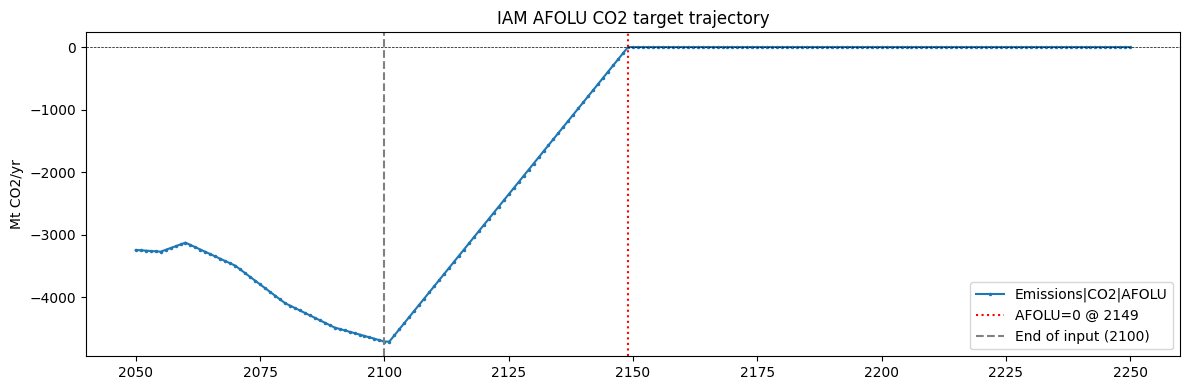

AFOLU at 2100: -4706.3 Mt CO2/yr
AFOLU at 2149: 0.0 Mt CO2/yr
AFOLU at 2150: 0.0 Mt CO2/yr


In [2]:
df = load_csv()
sc = filter_scenario(df)
afolu_target = get_variable(sc, 'Emissions|CO2|AFOLU')

fig, ax = plt.subplots(figsize=(12, 4))
afolu_target.loc[2050:2250].plot(ax=ax, marker='.', ms=3)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.axvline(cfg.YR_END_INPUT, color='gray', ls='--', label='End of input (2100)')
ax.set_ylabel('Mt CO2/yr'); ax.set_title('IAM AFOLU CO2 target trajectory')
ax.legend(); plt.tight_layout(); plt.show()

print(f"AFOLU at 2100: {afolu_target.loc[2100]:.1f} Mt CO2/yr")
print(f"AFOLU at 2149: {afolu_target.loc[2149]:.1f} Mt CO2/yr")
print(f"AFOLU at 2150: {afolu_target.loc[2150]:.1f} Mt CO2/yr")

## 2. Load Gridded Input States

Open the original LUH2 input (2024–2100) and compute grid-cell areas.  We only need the pre-2100 period for calibration — the extension files will be produced later in notebook 03.

In [3]:
# Original input (2024-2100)
ds_input = load_states()

lat = ds_input.lat.values
lon = ds_input.lon.values

# Grid-cell area (km²) from latitude — approximate spherical Earth
R_EARTH = 6371.0  # km
dlat = np.abs(np.diff(lat[:2]))[0]  # degrees
dlon = np.abs(np.diff(lon[:2]))[0]
lat_rad = np.deg2rad(lat)
cell_area = (R_EARTH**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(lat_rad)
# Broadcast to 2-D (lat, lon)
cell_area_2d = np.broadcast_to(cell_area[:, np.newaxis], (len(lat), len(lon)))

print(f"Input years: {int(ds_input.time.values[0])}–{int(ds_input.time.values[-1])}")
print(f"Grid: {len(lat)} x {len(lon)}")
print(f"Cell area range: {cell_area.min():.1f} - {cell_area.max():.1f} km²")

Input years: 2024–2100
Grid: 720 x 1440
Cell area range: 1.7 - 772.8 km²


## 3. Carbon Density and Cohort-Based Relaxation Model

We model two distinct flux channels:

### A) Transition flux — area change × carbon density
When land changes category, the carbon difference is released (deforestation) or sequestered (reforestation). This is proportional to the **rate of change** of land-use area. Unchanged from a standard bookkeeping model.

### B) Stock-change flux — cohort-based exponential relaxation

Regrowing forests don't accumulate carbon at a constant rate forever. Instead, carbon stocks **relax toward an equilibrium value** with an exponential timescale $\tau$:

$$\frac{dS}{dt} = \frac{C^{eq} - S(t)}{\tau}$$

For a stand reforested in year $t_r$, the uptake rate decays with stand age:

$$\text{uptake per unit area}(t) = \frac{C^{eq}_v}{\tau} \cdot e^{-(t - t_r)/\tau}$$

Young stands grow fast; old stands approach equilibrium and barely accumulate. This is the standard exponential approach-to-equilibrium used in bookkeeping carbon models (Houghton & Nassikas 2017).

We track each year's area increment as a **cohort**. The total stock-change flux is a convolution of the reforestation history with the exponential decay kernel:

$$F_{\text{stock}}(t) = -\sum_v \frac{C^{eq}_v}{\tau} \sum_{t_r} \Delta A_v(t_r) \cdot e^{-(t - t_r)/\tau}$$

This can be computed efficiently as a running sum: $G_v(t) = G_v(t-1) \cdot e^{-1/\tau} + \Delta A_v(t)$, so that $F_{\text{stock}}(t) = -\sum_v (C^{eq}_v / \tau) \cdot G_v(t)$.

| Category | $C$ density (tC/km²) | $C^{eq}$ (tC/km²) | Notes |
|----------|:-:|:-:|-------|
| Primary forest | 15,000 | — | Mature, no regrowth |
| Secondary forest | 8,000 | 12,000 | Relaxes toward primary; **key driver** |
| Primary non-forest | 1,500 | — | Equilibrium |
| Secondary non-forest | 1,000 | 800 | Recovers toward mature non-forest |
| Cropland (all) | 500 | — | Managed, no accumulation |
| Pasture | 800 | — | |
| Rangeland | 600 | — | |
| Urban | 200 | — | |
| Plantations | 6,000 | 8,000 | Managed timber regrowth |

**$\tau$ (shared relaxation timescale)** is calibrated against the IAM AFOLU trajectory via profile likelihood. Literature values: 50–100 yr for tropical secondary forest (Poorter et al. 2016), 100–200 yr for temperate.

In [4]:
# Carbon densities: tC per km2 (for transition flux)
CARBON_DENSITY = {
    'primf': 15_000, 'secdf':  8_000,
    'primn':  1_500, 'secdn':  1_000,
    'c3ann':    500, 'c3nfx':    500, 'c3per':    500,
    'c4ann':    500, 'c4per':    500,
    'pastr':    800, 'range':    600,
    'urban':    200, 'pltns':  6_000,
}

# Equilibrium carbon stock for regrowing land types (tC per km2).
# Represents the total carbon a regrowing stand will accumulate over its
# lifetime.  Non-regrowing types have C_EQ = 0.
C_EQ = {
    'primf':      0,  # mature forest, already at equilibrium
    'secdf': 12_000,  # relaxes toward primary forest stock — KEY DRIVER
    'primn':      0,
    'secdn':    800,  # recovering non-forest
    'c3ann':      0, 'c3nfx':  0, 'c3per':  0,
    'c4ann':      0, 'c4per':  0,
    'pastr':      0, 'range':  0,
    'urban':      0,
    'pltns':  8_000,  # managed plantation regrowth
}

# Regrowing land types (those with C_EQ > 0)
REGROW_VARS = [v for v in cfg.STATE_VARS if C_EQ[v] > 0]

TC_TO_MTCO2 = 3.667 / 1e6  # tC → Mt CO2


def stock_flux_for_tau(tau, area_incr, c_eq=C_EQ):
    """Compute stock-change flux for a given relaxation timescale.

    Uses the running-sum form of the cohort convolution:
        G_v(t) = G_v(t-1) * exp(-1/τ) + ΔA_v(t)
        flux(t) = -Σ_v (C_eq_v / τ) * G_v(t) * TC_TO_MTCO2

    Parameters
    ----------
    tau : float
        Relaxation timescale (years).
    area_incr : dict of arrays
        Global net area increment per year for each regrowing land type (km²).

    Returns
    -------
    flux : ndarray
        Stock-change flux (Mt CO₂/yr), negative = removal.
    """
    n = len(next(iter(area_incr.values())))
    decay = np.exp(-1.0 / tau)
    flux = np.zeros(n)
    for v in area_incr:
        ceq = c_eq[v]
        if ceq == 0:
            continue
        G = 0.0
        incr = area_incr[v]
        rate = ceq / tau * TC_TO_MTCO2
        for t in range(n):
            G = G * decay + incr[t]
            flux[t] += -rate * G
    return flux


print(f"{'Variable':8s}  {'C density':>10s}  {'C_eq':>10s}  {'Rate @ τ=50':>12s}")
print(f"{'':8s}  {'(tC/km²)':>10s}  {'(tC/km²)':>10s}  {'(tC/km²/yr)':>12s}")
print("-" * 47)
for v in cfg.STATE_VARS:
    r50 = f"{C_EQ[v]/50:.0f}" if C_EQ[v] > 0 else "—"
    print(f"  {v:6s}  {CARBON_DENSITY[v]:10,}  {C_EQ[v]:10,}  {r50:>12s}")
print(f"\nRegrowing land types: {REGROW_VARS}")

Variable   C density        C_eq   Rate @ τ=50
            (tC/km²)    (tC/km²)   (tC/km²/yr)
-----------------------------------------------
  primf       15,000           0             —
  secdf        8,000      12,000           240
  primn        1,500           0             —
  secdn        1,000         800            16
  c3ann          500           0             —
  c3nfx          500           0             —
  c3per          500           0             —
  c4ann          500           0             —
  c4per          500           0             —
  pastr          800           0             —
  range          600           0             —
  urban          200           0             —
  pltns        6,000       8,000           160

Regrowing land types: ['secdf', 'secdn', 'pltns']


## 4. Compute Transition Flux and Area Increments (Pre-2100)

Two quantities extracted from the gridded data:

- **Transition flux** (same as before): $-\sum_v \Delta f_{v,t} \times C_v \times A_{\text{cell}}$
- **Area increments**: the global net area change (km²) per year for each regrowing land type ($C^{eq}_v > 0$). These feed into the cohort convolution — the stock-change flux is computed from them via `stock_flux_for_tau()` and depends on the relaxation timescale $\tau$.

In [5]:
%%time
input_years = ds_input.time.values.astype(int)
n_input = len(input_years)
input_flux_years = input_years[1:]  # transitions: 2025-2100
n_pre = len(input_flux_years)

# ─── Channel 1: Transition flux (year-on-year Δarea × C_density) ───
transition_flux = np.zeros(n_pre)
for ti in range(1, n_input):
    af = 0.0
    for v in cfg.STATE_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    transition_flux[ti-1] = af

# ─── Area increments for regrowing types (global km² per year) ───
area_incr_pre = {v: np.zeros(n_pre) for v in REGROW_VARS}
for ti in range(1, n_input):
    for v in REGROW_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        area_incr_pre[v][ti-1] = np.nansum(delta * cell_area_2d)  # km²

print(f"Pre-2100: {n_pre} years ({input_flux_years[0]}–{input_flux_years[-1]})")
print(f"Transition flux range: {transition_flux.min():.0f} to {transition_flux.max():.0f} Mt CO₂/yr")
print(f"\nCumulative area change by 2100 (km²):")
for v in REGROW_VARS:
    cum = area_incr_pre[v].sum()
    print(f"  {v}: {cum:+,.0f} km²")

Pre-2100: 76 years (2025–2100)
Transition flux range: -8627 to 3652 Mt CO₂/yr

Cumulative area change by 2100 (km²):
  secdf: +12,984,505 km²
  secdn: +3,450,444 km²
  pltns: -643,574 km²
CPU times: user 16.1 s, sys: 2.36 s, total: 18.5 s
Wall time: 18.6 s


## 5. Calibrate: Profile Likelihood over τ

For a given relaxation timescale $\tau$, the stock-change flux is fully determined by the area increments via the exponential convolution. We then fit the linear model:

$$\text{AFOLU}^{\text{IAM}}_t \;\approx\; \beta \;+\; \alpha_{\text{trans}} \, F^{\text{trans}}_t \;+\; \alpha_{\text{stock}} \, F^{\text{stock}}_t(\tau)$$

with OLS for $[\beta, \alpha_{\text{trans}}, \alpha_{\text{stock}}]$.

**Profile likelihood**: scan over $\tau$ from 20–200 yr. At each value, compute the stock-change flux via the cohort convolution, fit the linear model, record R². The optimal $\tau$ maximises R².

This gives us one additional free parameter — the e-folding timescale for carbon stock recovery — with a clear physical meaning that can be compared against literature values as a sanity check.

In [6]:
y_iam = np.array([afolu_target.loc[yr] for yr in input_flux_years])

# ──── Profile likelihood: scan τ, fit [β, α_trans, α_stock] by OLS ────
tau_grid = np.arange(20, 201, 2)
r2_profile = np.zeros(len(tau_grid))
rmse_profile = np.zeros(len(tau_grid))
coefs_profile = np.zeros((len(tau_grid), 3))

for i, tau_try in enumerate(tau_grid):
    sf = stock_flux_for_tau(tau_try, area_incr_pre)
    X_try = np.column_stack([np.ones(n_pre), transition_flux, sf])
    c, _, _, _ = np.linalg.lstsq(X_try, y_iam, rcond=None)
    pred = X_try @ c
    ss_res = np.sum((y_iam - pred) ** 2)
    ss_tot = np.sum((y_iam - y_iam.mean()) ** 2)
    r2_profile[i] = 1 - ss_res / ss_tot
    rmse_profile[i] = np.sqrt(ss_res / n_pre)
    coefs_profile[i] = c

# Best τ from grid
best_idx = np.argmax(r2_profile)
tau_opt = tau_grid[best_idx]
beta, alpha_trans, alpha_stock = coefs_profile[best_idx]

# Recompute stock flux and calibrated prediction at optimal τ
stock_flux = stock_flux_for_tau(tau_opt, area_incr_pre)
X = np.column_stack([np.ones(n_pre), transition_flux, stock_flux])
calibrated_pre = X @ np.array([beta, alpha_trans, alpha_stock])
r2 = r2_profile[best_idx]
rmse = rmse_profile[best_idx]

# Out-of-sample validation (train ≤ 2085)
split_yr = 2085
train_mask = input_flux_years <= split_yr
test_mask = input_flux_years > split_yr

coefs_cv, _, _, _ = np.linalg.lstsq(X[train_mask], y_iam[train_mask], rcond=None)
pred_test = X[test_mask] @ coefs_cv
y_test = y_iam[test_mask]
ss_res_cv = np.sum((y_test - pred_test) ** 2)
ss_tot_cv = np.sum((y_test - y_test.mean()) ** 2)
r2_cv = 1 - ss_res_cv / ss_tot_cv if ss_tot_cv != 0 else float('nan')
rmse_cv = np.sqrt(np.mean((y_test - pred_test) ** 2))

print("=== Cohort-based calibration (exponential relaxation) ===\n")
print(f"  τ       = {tau_opt} yr         (carbon stock relaxation timescale)")
print(f"  β       = {beta:.1f} Mt CO₂/yr   (baseline AFOLU emissions)")
print(f"  α_trans = {alpha_trans:.3f}         (transition flux multiplier)")
print(f"  α_stock = {alpha_stock:.3f}         (stock-change multiplier)")
print(f"\n  Full-sample:    R² = {r2:.4f},  RMSE = {rmse:.0f} Mt CO₂/yr")
print(f"  Out-of-sample (train ≤{split_yr}):  R² = {r2_cv:.4f},  RMSE = {rmse_cv:.0f} Mt CO₂/yr")

# Initial uptake rate implied by calibration
print(f"\n  Implied initial uptake rates (at τ = {tau_opt} yr):")
for v in REGROW_VARS:
    rate = C_EQ[v] / tau_opt
    print(f"    {v}: C_eq/τ = {rate:.0f} tC/km²/yr")

# Channel contributions at key years
print(f"\n{'Year':>6s}  {'β':>8s}  {'α×Trans':>10s}  {'α×Stock':>10s}  {'Calib':>10s}  {'IAM':>10s}")
print("-" * 65)
for yr in [2030, 2050, 2070, 2090, 2100]:
    idx = np.searchsorted(input_flux_years, yr)
    ct = alpha_trans * transition_flux[idx]
    cs = alpha_stock * stock_flux[idx]
    print(f"  {yr:>4d}  {beta:8.1f}  {ct:10.1f}  {cs:10.1f}  {beta+ct+cs:10.1f}  {y_iam[idx]:10.1f}")

=== Cohort-based calibration (exponential relaxation) ===

  τ       = 200 yr         (carbon stock relaxation timescale)
  β       = 2069.6 Mt CO₂/yr   (baseline AFOLU emissions)
  α_trans = 0.085         (transition flux multiplier)
  α_stock = 2.723         (stock-change multiplier)

  Full-sample:    R² = 0.9557,  RMSE = 425 Mt CO₂/yr
  Out-of-sample (train ≤2085):  R² = -63.6371,  RMSE = 909 Mt CO₂/yr

  Implied initial uptake rates (at τ = 200 yr):
    secdf: C_eq/τ = 60 tC/km²/yr
    secdn: C_eq/τ = 4 tC/km²/yr
    pltns: C_eq/τ = 40 tC/km²/yr

  Year         β     α×Trans     α×Stock       Calib         IAM
-----------------------------------------------------------------
  2030    2069.6        89.0      -119.3      2039.3      1754.3
  2050    2069.6      -349.7     -5168.5     -3448.6     -3242.5
  2070    2069.6      -240.4     -5982.9     -4153.7     -3493.2
  2090    2069.6       -43.5     -5967.5     -3941.4     -4482.6
  2100    2069.6       -59.9     -5938.1     -3928.

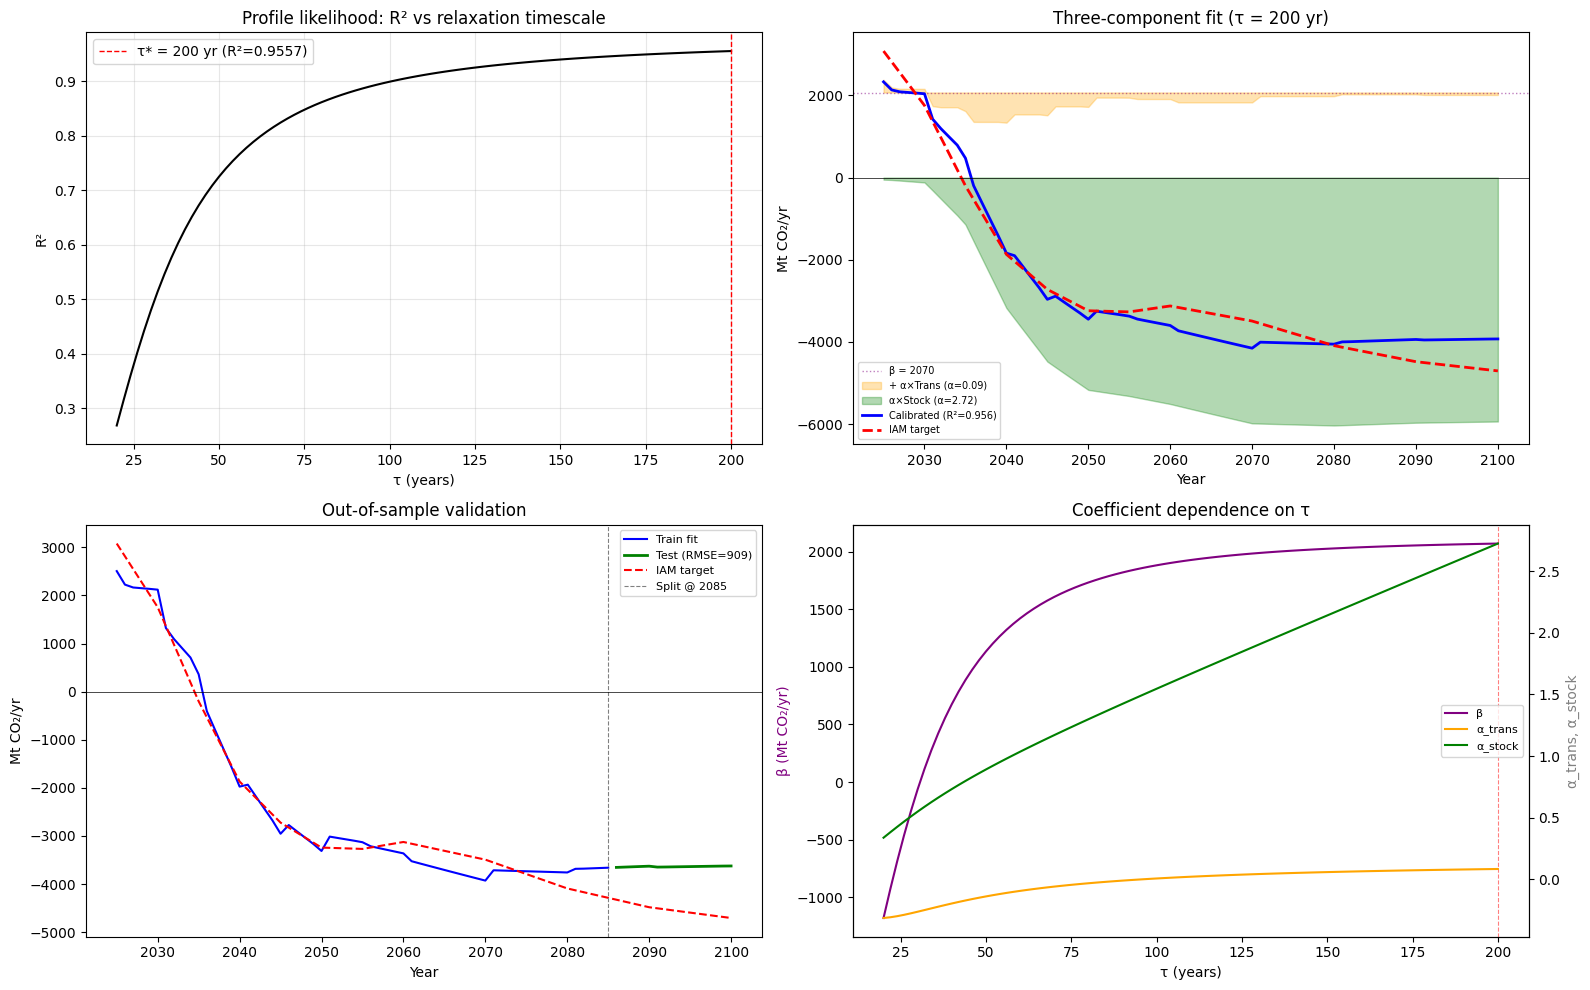

Correlation with IAM: calibrated r = 0.9776
τ range where R² > 0.95: 178–200 yr


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: τ profile likelihood
ax = axes[0, 0]
ax.plot(tau_grid, r2_profile, 'k-', lw=1.5)
ax.axvline(tau_opt, color='r', ls='--', lw=1, label=f'τ* = {tau_opt} yr (R²={r2:.4f})')
ax.set_xlabel('τ (years)'); ax.set_ylabel('R²')
ax.set_title('Profile likelihood: R² vs relaxation timescale')
ax.legend(); ax.grid(True, alpha=0.3)

# Top-right: three components at optimal τ
ax = axes[0, 1]
ax.axhline(beta, color='purple', ls=':', lw=1, alpha=0.5, label=f'β = {beta:.0f}')
ax.fill_between(input_flux_years, beta, beta + alpha_trans * transition_flux,
                alpha=0.3, color='orange', label=f'+ α×Trans (α={alpha_trans:.2f})')
ax.fill_between(input_flux_years, 0, alpha_stock * stock_flux,
                alpha=0.3, color='green', label=f'α×Stock (α={alpha_stock:.2f})')
ax.plot(input_flux_years, calibrated_pre, 'b-', lw=2, label=f'Calibrated (R²={r2:.3f})')
ax.plot(input_flux_years, y_iam, 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title(f'Three-component fit (τ = {tau_opt} yr)')
ax.legend(fontsize=7)

# Bottom-left: out-of-sample validation
ax = axes[1, 0]
train_pred = X[train_mask] @ coefs_cv
ax.plot(input_flux_years[train_mask], train_pred, 'b-', lw=1.5, label='Train fit')
ax.plot(input_flux_years[test_mask], pred_test, 'g-', lw=2,
        label=f'Test (RMSE={rmse_cv:.0f})')
ax.plot(input_flux_years, y_iam, 'r--', lw=1.5, label='IAM target')
ax.axvline(split_yr, color='gray', ls='--', lw=0.8, label=f'Split @ {split_yr}')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Out-of-sample validation')
ax.legend(fontsize=8)

# Bottom-right: how linear coefficients vary with τ
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(tau_grid, coefs_profile[:, 0], 'purple', lw=1.5, label='β')
ax2.plot(tau_grid, coefs_profile[:, 1], 'orange', lw=1.5, label='α_trans')
ax2.plot(tau_grid, coefs_profile[:, 2], 'green', lw=1.5, label='α_stock')
ax.axvline(tau_opt, color='r', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('τ (years)'); ax.set_ylabel('β (Mt CO₂/yr)', color='purple')
ax2.set_ylabel('α_trans, α_stock', color='gray')
ax.set_title('Coefficient dependence on τ')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

plt.tight_layout(); plt.show()

corr_cal = np.corrcoef(calibrated_pre, y_iam)[0, 1]
print(f"Correlation with IAM: calibrated r = {corr_cal:.4f}")
print(f"τ range where R² > 0.95: "
      f"{tau_grid[r2_profile > 0.95].min()}–{tau_grid[r2_profile > 0.95].max()} yr"
      if np.any(r2_profile > 0.95) else "No τ achieves R² > 0.95")

## 6. Derive AFOLU-Consistent Ramp $r(t)$

Instead of using an arbitrary linear ramp, we **invert the calibrated model** to solve for the rate multiplier $r(t)$ that reproduces the IAM's AFOLU trajectory post-2100.

At each year $t > 2100$, the calibrated model gives:

$$\text{AFOLU}_{\text{target}}(t) = r(t) \cdot \underbrace{\left[\beta + \alpha_{\text{trans}} \cdot F^{\text{trans}}_{\text{unit}} + \alpha_{\text{stock}} \cdot S_{\text{new,unit}}\right]}_{\text{constant: flux per unit rate}} + \alpha_{\text{stock}} \cdot S_{\text{prev}}(t)$$

where:
- $F^{\text{trans}}_{\text{unit}}$: transition flux at full 2100 rates
- $S_{\text{new,unit}}$: stock-change flux from one year of area increment at full rate
- $S_{\text{prev}}(t)$: stock-change flux from all previous cohorts (decaying with $\tau$)

Solving: $r(t) = \frac{\text{AFOLU}_{\text{target}}(t) - \alpha_{\text{stock}} \cdot S_{\text{prev}}(t)}{\beta + \alpha_{\text{trans}} \cdot F^{\text{trans}}_{\text{unit}} + \alpha_{\text{stock}} \cdot S_{\text{new,unit}}}$

This is sequential: each year's $r(t)$ determines the new cohort that affects $S_{\text{prev}}$ for subsequent years.

In [8]:
# ─── Unit-rate quantities (what happens when r=1 for one year) ───
rates_at_2100 = rates_2100(ds_input)

# Transition flux at unit rate: same as applying full 2100 rates to cell areas
F_trans_unit = 0.0
for v in cfg.STATE_VARS:
    F_trans_unit += np.nansum(-rates_at_2100[v] * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2

# Area increments at unit rate for each regrowing type
dA_unit = {}
for v in REGROW_VARS:
    dA_unit[v] = np.nansum(rates_at_2100[v] * cell_area_2d)  # km²

# Stock-change flux from one unit of new area
S_new_unit = 0.0
for v in REGROW_VARS:
    ceq = C_EQ[v]
    if ceq == 0:
        continue
    S_new_unit += -(ceq / tau_opt) * dA_unit[v] * TC_TO_MTCO2

# Constant denominator for the forward solve
denom = beta + alpha_trans * F_trans_unit + alpha_stock * S_new_unit

print(f"F_trans_unit = {F_trans_unit:.1f} Mt CO₂/yr  (transition flux at full 2100 rates)")
print(f"S_new_unit   = {S_new_unit:.1f} Mt CO₂/yr  (stock-change from one year of unit area)")
print(f"Denominator  = {denom:.1f} Mt CO₂/yr  (total flux per unit rate)")
print(f"  β component:       {beta:.1f}")
print(f"  α_trans component: {alpha_trans * F_trans_unit:.1f}")
print(f"  α_stock component: {alpha_stock * S_new_unit:.1f}")

# ─── Reconstruct G_v at end of pre-2100 period ───
decay = np.exp(-1.0 / tau_opt)
G_end_pre = {}
for v in REGROW_VARS:
    G = 0.0
    for t in range(n_pre):
        G = G * decay + area_incr_pre[v][t]
    G_end_pre[v] = G

# ─── Forward solve for r(t), 2101–2500 ───
ext_years = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)
n_ext = len(ext_years)
r_derived = np.zeros(n_ext)
afolu_reconstructed = np.zeros(n_ext)
stock_from_prev = np.zeros(n_ext)   # track stock-change from old cohorts

# Working copies of G
G_work = {v: G_end_pre[v] for v in REGROW_VARS}

for t in range(n_ext):
    yr = ext_years[t]

    # IAM target at this year
    if yr in afolu_target.index:
        target_t = afolu_target.loc[yr]
    else:
        target_t = 0.0  # beyond CSV range, assume zero

    # Stock-change flux from previous cohorts (before adding this year's increment)
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        S_prev += -(ceq / tau_opt) * G_work[v] * decay * TC_TO_MTCO2

    stock_from_prev[t] = alpha_stock * S_prev

    # Solve for r(t)
    r_t = (target_t - alpha_stock * S_prev) / denom
    # Clamp to [0, 1] — can't reverse land-use change or exceed 2100 rates
    r_t = np.clip(r_t, 0.0, 1.0)
    r_derived[t] = r_t

    # Update G_v with this year's area increment
    for v in REGROW_VARS:
        G_work[v] = G_work[v] * decay + r_t * dA_unit[v]

    # Reconstruct AFOLU flux for verification
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        S_full += -(ceq / tau_opt) * G_work[v] * TC_TO_MTCO2
    afolu_reconstructed[t] = beta * r_t + alpha_trans * F_trans_unit * r_t + alpha_stock * S_full

# Check how well we match the target
iam_ext = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                     for yr in ext_years])
residual = afolu_reconstructed - iam_ext
ramp_idx = ext_years <= cfg.YR_AFOLU_ZERO

print(f"\nForward solve complete: {n_ext} years ({ext_years[0]}–{ext_years[-1]})")
print(f"\n{'Year':>6s}  {'r(t)':>8s}  {'IAM':>10s}  {'Recon':>10s}  {'Resid':>8s}")
print("-" * 50)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    idx = np.searchsorted(ext_years, yr)
    print(f"  {yr:>4d}  {r_derived[idx]:8.4f}  {iam_ext[idx]:10.1f}  "
          f"{afolu_reconstructed[idx]:10.1f}  {residual[idx]:8.1f}")

# Year r(t) first reaches zero
zero_idx = np.where(r_derived < 1e-6)[0]
if len(zero_idx) > 0:
    print(f"\n★ r(t) reaches zero at year {ext_years[zero_idx[0]]}")
else:
    print(f"\n★ r(t) never reaches zero in extension period")

F_trans_unit = -704.3 Mt CO₂/yr  (transition flux at full 2100 rates)
S_new_unit   = -9.8 Mt CO₂/yr  (stock-change from one year of unit area)
Denominator  = 1982.9 Mt CO₂/yr  (total flux per unit rate)
  β component:       2069.6
  α_trans component: -59.9
  α_stock component: -26.8

Forward solve complete: 400 years (2101–2500)

  Year      r(t)         IAM       Recon     Resid
--------------------------------------------------
  2101    0.6062     -4706.3     -4706.3       0.0
  2110    1.0000     -3823.9     -3849.9     -26.0
  2125    1.0000     -2353.2     -3814.4   -1461.2
  2140    1.0000      -882.4     -3781.4   -2899.0
  2149    1.0000         0.0     -3762.8   -3762.8
  2150    1.0000         0.0     -3760.8   -3760.8
  2200    1.0000         0.0     -3671.8   -3671.8
  2300    1.0000         0.0     -3548.6   -3548.6

★ r(t) never reaches zero in extension period


## 7. Compare Derived Ramp vs Linear Ramp

The AFOLU-consistent ramp encodes the carbon cycle dynamics learned from the pre-2100 period. It should differ from the linear ramp because of the stock-change channel: as forest cohorts age, their carbon uptake diminishes, so the rate of land-use change doesn't need to decrease as quickly to achieve the same AFOLU trajectory.

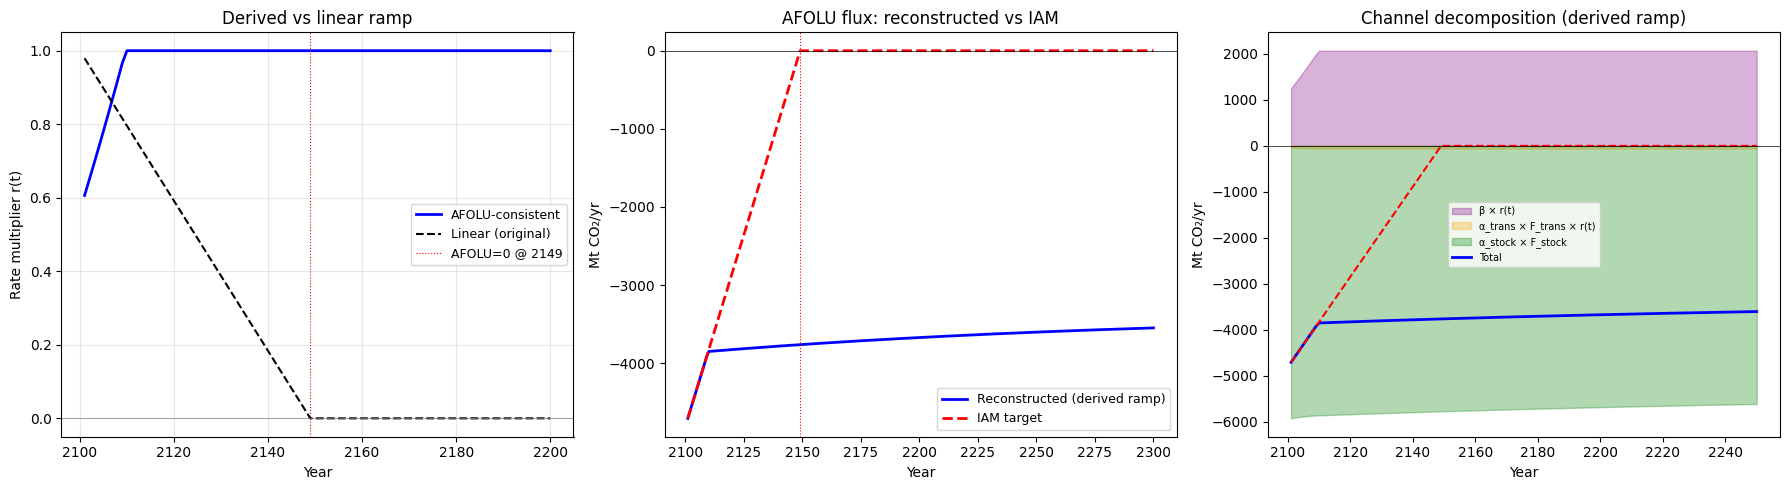

Ramp difference (derived - linear) over 2101-2150:
  Mean: +0.4809
  Max:  +1.0000 at year 2149
  Min:  -0.3734 at year 2101


In [9]:
from src.data import afolu_ramp

linear_ramp = afolu_ramp(ext_years)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: ramp comparison
ax = axes[0]
ax.plot(ext_years[:100], r_derived[:100], 'b-', lw=2, label='AFOLU-consistent')
ax.plot(ext_years[:100], linear_ramp[:100], 'k--', lw=1.5, label='Linear (original)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8, label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.set_xlabel('Year'); ax.set_ylabel('Rate multiplier r(t)')
ax.set_title('Derived vs linear ramp')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Middle: AFOLU trajectory match
ax = axes[1]
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'b-', lw=2, label='Reconstructed (derived ramp)')
ax.plot(ext_years[:200], iam_ext[:200], 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU flux: reconstructed vs IAM')
ax.legend(fontsize=9)

# Right: decomposition of derived ramp
ax = axes[2]
beta_component = beta * r_derived
trans_component = alpha_trans * F_trans_unit * r_derived
stock_component = afolu_reconstructed - beta_component - trans_component
ax.fill_between(ext_years[:150], 0, beta_component[:150],
                alpha=0.3, color='purple', label='β × r(t)')
ax.fill_between(ext_years[:150], 0, trans_component[:150],
                alpha=0.3, color='orange', label='α_trans × F_trans × r(t)')
ax.fill_between(ext_years[:150], 0, stock_component[:150],
                alpha=0.3, color='green', label='α_stock × F_stock')
ax.plot(ext_years[:150], afolu_reconstructed[:150], 'b-', lw=2, label='Total')
ax.plot(ext_years[:150], iam_ext[:150], 'r--', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Channel decomposition (derived ramp)')
ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# Quantify difference from linear
ramp_diff = r_derived[:50] - linear_ramp[:50]
print(f"Ramp difference (derived - linear) over 2101-2150:")
print(f"  Mean: {ramp_diff.mean():+.4f}")
print(f"  Max:  {ramp_diff.max():+.4f} at year {ext_years[np.argmax(ramp_diff)]}")
print(f"  Min:  {ramp_diff.min():+.4f} at year {ext_years[np.argmin(ramp_diff)]}")

=== Committed stock-change removals (r=0) ===
  τ = 200 yr, α_stock = 2.723
  2101: -5908 Mt CO₂/yr
  2110: -5648 Mt CO₂/yr
  2125: -5240 Mt CO₂/yr
  2149: -4648 Mt CO₂/yr
  2200: -3602 Mt CO₂/yr
  2300: -2184 Mt CO₂/yr

  AFOLU target at 2101: -4706
  AFOLU target at 2149: +0

  ★ Gap at 2149 (committed - target): -4648 Mt CO₂/yr
    This is the flux we CANNOT eliminate with r(t) ∈ [0,1]

=== Option A: Unclamped r(t) ===
    Year      r(t)       AFOLU      Target     Resid
  --------------------------------------------------
  2101    +0.6062     -4706.3     -4706.3       0.0
  2110    +1.0131     -3823.9     -3823.9      -0.0
  2125    +1.8103     -2353.2     -2353.2      -0.0
  2140    +2.7736      -882.4      -882.4       0.0
  2149    +3.4405        -0.0         0.0      -0.0
  2150    +3.4695         0.0         0.0       0.0
  2200    +5.2836         0.0         0.0       0.0
  2300   +12.2535        -0.0         0.0      -0.0

  ★ Minimum r(t) in ramp period: +0.6062
    → r < 

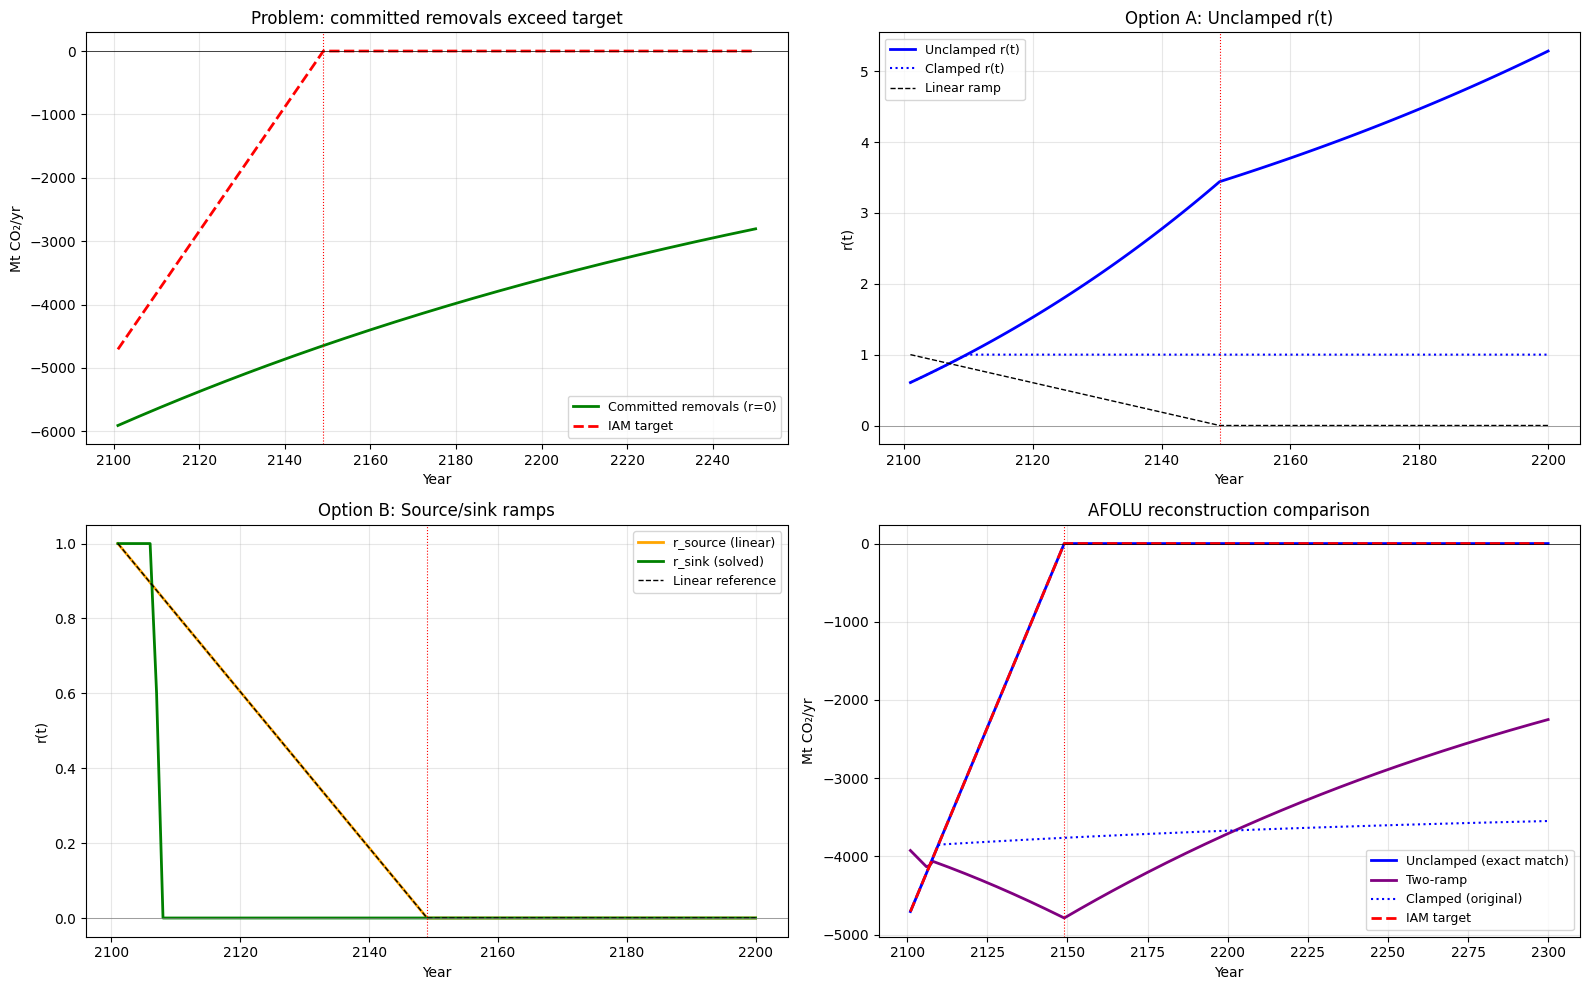

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: Can a 50-year ramp to zero work, and what helps?
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Committed removals with r(t) = 0 for all t > 2100 ──
# If we stop ALL new land-use change, what stock-change flux remains?
n_diag = 400  # 2101–2500
committed = np.zeros(n_diag)
G_zero = {v: G_end_pre[v] for v in REGROW_VARS}
for t in range(n_diag):
    S = 0.0
    for v in REGROW_VARS:
        G_zero[v] *= decay  # age existing cohorts, add nothing new
        ceq = C_EQ[v]
        if ceq == 0: continue
        S += -(ceq / tau_opt) * G_zero[v] * TC_TO_MTCO2
    committed[t] = alpha_stock * S

print("=== Committed stock-change removals (r=0) ===")
print(f"  τ = {tau_opt} yr, α_stock = {alpha_stock:.3f}")
for yr in [2101, 2110, 2125, 2149, 2200, 2300]:
    i = yr - 2101
    print(f"  {yr}: {committed[i]:+.0f} Mt CO₂/yr")

# IAM target at key years
iam_diag = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                       for yr in ext_years])
print(f"\n  AFOLU target at 2101: {iam_diag[0]:+.0f}")
print(f"  AFOLU target at 2149: {iam_diag[48]:+.0f}")
print(f"\n  ★ Gap at 2149 (committed - target): {committed[48] - iam_diag[48]:+.0f} Mt CO₂/yr")
print(f"    This is the flux we CANNOT eliminate with r(t) ∈ [0,1]")

# ── 2. Option A: Unclamped r(t) – allow r < 0 ──
# Negative r = reverse land-use change direction (some deforestation)
r_unclamped = np.zeros(n_diag)
afolu_unclamped = np.zeros(n_diag)
G_unc = {v: G_end_pre[v] for v in REGROW_VARS}

for t in range(n_diag):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / tau_opt) * G_unc[v] * decay * TC_TO_MTCO2
    r_t = (target_t - alpha_stock * S_prev) / denom
    r_unclamped[t] = r_t  # no clamp!
    for v in REGROW_VARS:
        G_unc[v] = G_unc[v] * decay + r_t * dA_unit[v]
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / tau_opt) * G_unc[v] * TC_TO_MTCO2
    afolu_unclamped[t] = beta * r_t + alpha_trans * F_trans_unit * r_t + alpha_stock * S_full

resid_unc = afolu_unclamped - iam_diag
print("\n=== Option A: Unclamped r(t) ===")
print(f"  {'Year':>6s}  {'r(t)':>8s}  {'AFOLU':>10s}  {'Target':>10s}  {'Resid':>8s}")
print("  " + "-" * 50)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    i = yr - 2101
    print(f"  {yr:>4d}   {r_unclamped[i]:+8.4f}  {afolu_unclamped[i]:10.1f}  "
          f"{iam_diag[i]:10.1f}  {resid_unc[i]:8.1f}")
min_r = r_unclamped[:50].min()
print(f"\n  ★ Minimum r(t) in ramp period: {min_r:+.4f}")
print(f"    → r < 0 means REVERSING {abs(min_r)*100:.1f}% of 2100 land-use change rates")

# ── 3. Option B: Per-type ramps (source/sink decomposition) ──
# Split transitions into those that EMIT (deforestation-like) and REMOVE (reforestation-like)
# Source types: rate_2100 < 0 (area shrinking → releasing carbon)
# Sink types: rate_2100 > 0 (area growing → absorbing carbon)

rates = rates_2100(ds_input)

# Classify by net rate direction at 2100 (summed over globe, weighted by carbon)
F_trans_source = 0.0  # flux from shrinking types (positive = emissions)
F_trans_sink = 0.0    # flux from growing types (negative = removals)
dA_unit_source = {v: 0.0 for v in REGROW_VARS}
dA_unit_sink = {v: 0.0 for v in REGROW_VARS}
S_new_source = 0.0
S_new_sink = 0.0

print("\n=== Option B: Per-type source/sink decomposition ===")
print(f"  {'Type':8s}  {'Net rate':>12s}  {'F_trans':>10s}  {'Channel':>8s}")
print("  " + "-" * 48)
for v in cfg.STATE_VARS:
    global_area_rate = np.nansum(rates[v] * cell_area_2d)  # km²/yr
    ftv = np.nansum(-rates[v] * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    channel = "source" if ftv > 0 else "sink"
    print(f"  {v:8s} {global_area_rate:+12.0f}  {ftv:+10.1f}  {channel:>8s}")
    if ftv > 0:
        F_trans_source += ftv
    else:
        F_trans_sink += ftv
    # Classify area increments for regrowing types
    if v in REGROW_VARS:
        ceq = C_EQ[v]
        area_rate_v = np.nansum(rates[v] * cell_area_2d)
        snew_v = -(ceq / tau_opt) * area_rate_v * TC_TO_MTCO2
        if ftv > 0:  # this type is a net source
            dA_unit_source[v] = area_rate_v
            S_new_source += snew_v
        else:
            dA_unit_sink[v] = area_rate_v
            S_new_sink += snew_v

print(f"\n  F_trans_source = {F_trans_source:+.1f} Mt CO₂/yr (emitting transitions)")
print(f"  F_trans_sink   = {F_trans_sink:+.1f} Mt CO₂/yr (removing transitions)")
print(f"  S_new_source   = {S_new_source:+.1f} Mt CO₂/yr")
print(f"  S_new_sink     = {S_new_sink:+.1f} Mt CO₂/yr")

# Two-ramp forward solve:
# r_source × [β_share + α_t × F_source + α_s × S_new_source]
# + r_sink × [β_share + α_t × F_sink + α_s × S_new_sink]
# + α_s × S_committed(t)
# = target

# Strategy: r_source ramps linearly 1→0 over 50 years
# Solve for r_sink at each step
denom_sink = alpha_trans * F_trans_sink + alpha_stock * S_new_sink
denom_source = alpha_trans * F_trans_source + alpha_stock * S_new_source

print(f"\n  Denominator (source): β×f_src + α_t × F_source + α_s × S_new_source = "
      f"{denom_source:+.1f}")
print(f"  Denominator (sink):   β×f_snk + α_t × F_sink   + α_s × S_new_sink   = "
      f"{denom_sink:+.1f}")

# Forward solve with two ramps
r_source_2r = np.zeros(n_diag)
r_sink_2r = np.zeros(n_diag)
afolu_2r = np.zeros(n_diag)
G_2r = {v: G_end_pre[v] for v in REGROW_VARS}
linear_50 = np.clip(1 - np.arange(n_diag) / (cfg.YR_AFOLU_ZERO - cfg.YR_END_INPUT - 1), 0, 1)

for t in range(n_diag):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    r_src = linear_50[t]
    r_source_2r[t] = r_src

    # committed stock change from previous cohorts
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / tau_opt) * G_2r[v] * decay * TC_TO_MTCO2

    # Solve for r_sink:
    # target = β·(f_src·r_src + f_snk·r_sink) + α_t·(F_src·r_src + F_snk·r_sink)
    #        + α_s·(S_prev_committed + S_new_src·r_src + S_new_snk·r_sink)
    # Hmm, β is a constant intercept, not per-channel. Let's split β proportionally
    # Actually β is the baseline offset. When both r=1, AFOLU = β + α_t·F_trans + α_s·S
    # When r_src and r_sink differ, the controlled part is:
    # target = β + α_t·(F_src·r_src + F_snk·r_sink) + α_s·(S_committed + S_new_src·r_src + S_new_snk·r_sink)
    # But β should also scale... β is the residual from calibration, not clearly split.
    # Simple approach: β scales with average of the two ramps
    # Actually, let's attribute β to a weighted mix: β_src + β_sink
    # Alternatively: β scales with the dominant channel
    # Simplest: β × r_src (attribute baseline to source channel)
    # This is a modeling choice.
    
    # Let's try: β scales with mean(r_src, r_sink) -- or we solve for r_sink and
    # attribute β entirely to r_source (since β > 0, it's an emission offset)
    source_contrib = beta * r_src + alpha_trans * F_trans_source * r_src + alpha_stock * S_new_source * r_src
    needed_from_sink = target_t - alpha_stock * S_prev - source_contrib
    
    if abs(alpha_trans * F_trans_sink + alpha_stock * S_new_sink) > 1e-6:
        r_snk = needed_from_sink / (alpha_trans * F_trans_sink + alpha_stock * S_new_sink)
    else:
        r_snk = 0.0
    r_snk = np.clip(r_snk, 0.0, 1.0)
    r_sink_2r[t] = r_snk

    # Update cohorts
    for v in REGROW_VARS:
        r_v = r_src if dA_unit_source.get(v, 0) != 0 else r_snk
        # Actually need to handle per-type properly
        area_src = dA_unit_source.get(v, 0.0)
        area_snk = dA_unit_sink.get(v, 0.0)
        G_2r[v] = G_2r[v] * decay + r_src * area_src + r_snk * area_snk

    # Reconstruct
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / tau_opt) * G_2r[v] * TC_TO_MTCO2
    afolu_2r[t] = (beta * r_src +
                   alpha_trans * (F_trans_source * r_src + F_trans_sink * r_snk) +
                   alpha_stock * S_full)

resid_2r = afolu_2r - iam_diag
print(f"\n  Two-ramp solve (source=linear, sink=solved):")
print(f"  {'Year':>6s}  {'r_src':>8s}  {'r_sink':>8s}  {'AFOLU':>10s}  {'Target':>10s}  {'Resid':>8s}")
print("  " + "-" * 56)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    i = yr - 2101
    print(f"  {yr:>4d}   {r_source_2r[i]:8.4f}  {r_sink_2r[i]:8.4f}  "
          f"{afolu_2r[i]:10.1f}  {iam_diag[i]:10.1f}  {resid_2r[i]:8.1f}")

# ── 4. Summary plot ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(ext_years[:150], committed[:150], 'g-', lw=2, label='Committed removals (r=0)')
ax.plot(ext_years[:150], iam_diag[:150], 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Problem: committed removals exceed target')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ext_years[:100], r_unclamped[:100], 'b-', lw=2, label='Unclamped r(t)')
ax.plot(ext_years[:100], r_derived[:100], 'b:', lw=1.5, label='Clamped r(t)')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear ramp')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Option A: Unclamped r(t)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(ext_years[:100], r_source_2r[:100], '-', color='orange', lw=2, label='r_source (linear)')
ax.plot(ext_years[:100], r_sink_2r[:100], '-', color='green', lw=2, label='r_sink (solved)')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear reference')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Option B: Source/sink ramps')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(ext_years[:200], afolu_unclamped[:200], 'b-', lw=2, label='Unclamped (exact match)')
ax.plot(ext_years[:200], afolu_2r[:200], '-', color='purple', lw=2, label='Two-ramp')
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'b:', lw=1.5, label='Clamped (original)')
ax.plot(ext_years[:200], iam_diag[:200], 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU reconstruction comparison')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [14]:
# Key summary numbers
print("KEY NUMBERS")
print(f"  Committed removals at 2149 (r=0): {committed[48]:+.0f} Mt CO₂/yr")
print(f"  IAM target at 2149:               {iam_diag[48]:+.0f} Mt CO₂/yr")
print(f"  Gap (cannot close with r∈[0,1]):  {committed[48] - iam_diag[48]:+.0f} Mt CO₂/yr")
print()
print(f"Option A — unclamped r(t):")
print(f"  min r(t): {r_unclamped[:50].min():+.4f} at year {ext_years[np.argmin(r_unclamped[:50])]}")
print(f"  max |residual| in ramp: {np.max(np.abs(resid_unc[:50])):.1f} Mt CO₂/yr")
print(f"  r at 2149: {r_unclamped[48]:+.4f}")
print(f"  Does AFOLU reach zero by 2149? {np.abs(afolu_unclamped[48]) < 10}")
print()
print(f"Option B — two ramps (source=linear, sink=solved):")
print(f"  r_sink min: {r_sink_2r[:50].min():.4f}, max: {r_sink_2r[:50].max():.4f}")
print(f"  max |residual| in ramp: {np.max(np.abs(resid_2r[:50])):.1f} Mt CO₂/yr")
print(f"  Does two-ramp match IAM? {np.max(np.abs(resid_2r[:50])) < 100}")


KEY NUMBERS
  Committed removals at 2149 (r=0): -4648 Mt CO₂/yr
  IAM target at 2149:               +0 Mt CO₂/yr
  Gap (cannot close with r∈[0,1]):  -4648 Mt CO₂/yr

Option A — unclamped r(t):
  min r(t): +0.6062 at year 2101
  max |residual| in ramp: 0.0 Mt CO₂/yr
  r at 2149: +3.4405
  Does AFOLU reach zero by 2149? True

Option B — two ramps (source=linear, sink=solved):
  r_sink min: 0.0000, max: 1.0000
  max |residual| in ramp: 4788.8 Mt CO₂/yr
  Does two-ramp match IAM? False


In [15]:
# How much do committed removals change with α_stock constraint?
print(f"Current calibration: α_stock = {alpha_stock:.3f}, τ = {tau_opt}")
print(f"  Committed at 2149: {committed[48]:+.0f} Mt CO₂/yr")
print(f"  Committed at 2149 if α_stock=1: {committed[48]/alpha_stock:+.0f} Mt CO₂/yr")
print()
# What τ would we need for committed removals to be < 100 Mt CO₂/yr at 2149?
# committed(49) = committed(0) * exp(-49/τ) → need committed(0)*exp(-49/τ_eff) < 100
# committed(0) = committed at year 2101
c0 = committed[0]
print(f"Committed at 2101: {c0:+.0f} Mt CO₂/yr")
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tau_needed = -49 / np.log(100 / abs(c0)) if abs(c0) > 100 else float('inf')
print(f"τ needed for |committed(2149)| < 100: {tau_needed:.0f} yr")
print(f"  (vs current τ = {tau_opt}, literature range 50-200)")
print()

# Unclamped r(t) interpretation:
# r(t) starts at 0.61 and INCREASES to 3.44
# This means the model needs MORE transitions (not fewer) to reach AFOLU=0
print("INTERPRETATION:")
print(f"  Unclamped r increases from {r_unclamped[0]:+.2f} to {r_unclamped[48]:+.2f}")
print(f"  → To reach AFOLU=0, we need to INCREASE land-use transition rates")
print(f"    by {r_unclamped[48]:.1f}× to create enough EMISSIONS to offset")
print(f"    -{abs(committed[48]):.0f} Mt CO₂/yr of committed removals")
print()
# What if the ramp period were 100 yr instead of 50?
frac_50 = np.exp(-49/tau_opt)
frac_100 = np.exp(-99/tau_opt)
print(f"Decay of committed removals:")
print(f"  At 50 yr (t=2149): {frac_50:.1%} remains → {committed[0]*frac_50/committed[0]*committed[48]:.0f} Mt CO₂/yr")
print(f"  At 100 yr (t=2199): {frac_100:.1%} remains")
print(f"  Half-life: {tau_opt * np.log(2):.0f} yr")


Current calibration: α_stock = 2.723, τ = 200
  Committed at 2149: -4648 Mt CO₂/yr
  Committed at 2149 if α_stock=1: -1707 Mt CO₂/yr

Committed at 2101: -5908 Mt CO₂/yr
τ needed for |committed(2149)| < 100: 12 yr
  (vs current τ = 200, literature range 50-200)

INTERPRETATION:
  Unclamped r increases from +0.61 to +3.44
  → To reach AFOLU=0, we need to INCREASE land-use transition rates
    by 3.4× to create enough EMISSIONS to offset
    -4648 Mt CO₂/yr of committed removals

Decay of committed removals:
  At 50 yr (t=2149): 78.3% remains → -3638 Mt CO₂/yr
  At 100 yr (t=2199): 61.0% remains
  Half-life: 139 yr


Constrained calibration: τ=76, β=774.5, α_trans=-0.047, α_stock=1.000, R²=0.8178

=== Constrained calibration: committed removals ===
  τ = 76 yr, half-life = 53 yr
  Committed at 2101: -3800 Mt CO₂/yr
  Committed at 2149: -2021 Mt CO₂/yr
  Decay fraction at 2149: 52.5%
  Gap at 2149: -2021 Mt CO₂/yr

=== Clamped r(t) in [0,1] — constrained calibration ===
  2101: r=0.0000  AFOLU=-3800  target=-4706  resid=+906
  2125: r=0.5879  AFOLU=-2353  target=-2353  resid=-0
  2149: r=1.0000  AFOLU=-1778  target=+0  resid=-1778
  2200: r=1.0000  AFOLU=-1482  target=+0  resid=-1482

=== Unclamped r(t) — constrained calibration ===
  r range [2101-2149]: [-1.1589, +3.3412]
  r at 2149: +3.2770
  Max |error| in ramp: 0.0


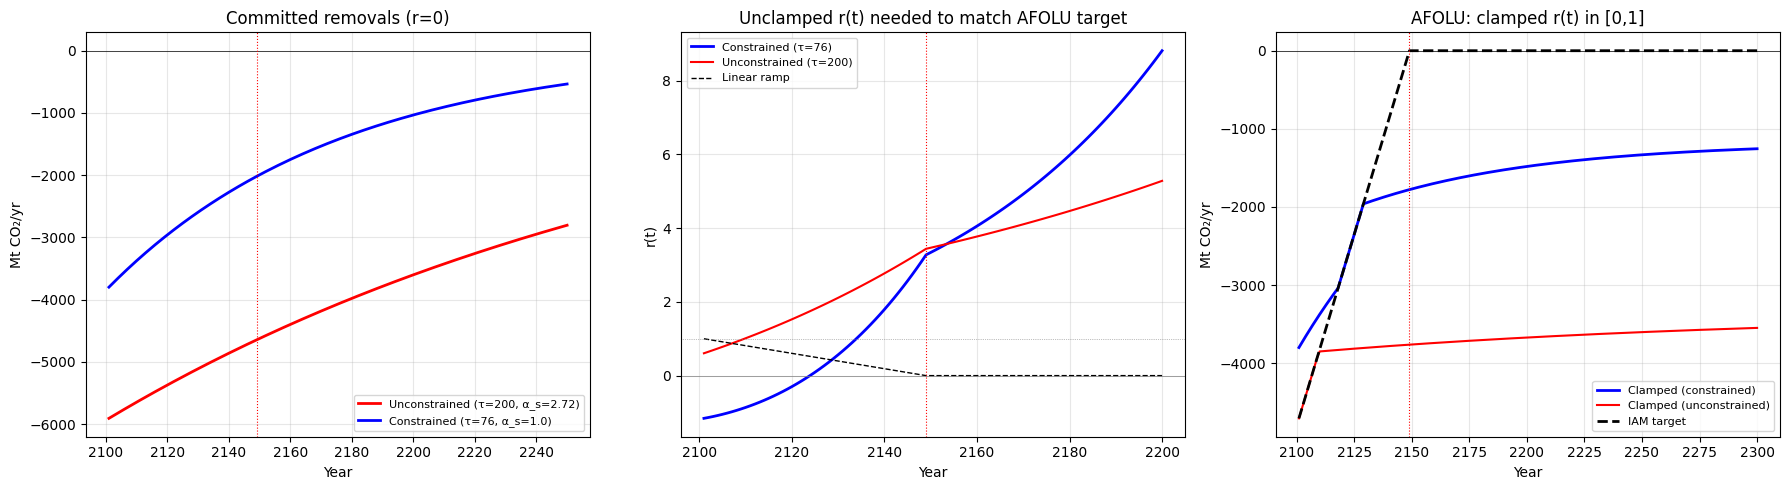

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# CONSTRAINED calibration (α_stock = 1) — re-derive and test
# ═══════════════════════════════════════════════════════════════════════

# Grid search with α_stock fixed at 1.0
best_r2_c, best_tau_c = -np.inf, 50
for tau_try in range(20, 201, 2):
    sf = stock_flux_for_tau(tau_try, area_incr_pre)
    y_adj = y_iam - sf  # subtract stock-change with α_stock=1
    X2 = np.column_stack([np.ones(n_pre), transition_flux])
    c2, _, _, _ = np.linalg.lstsq(X2, y_adj, rcond=None)
    pred = X2 @ c2 + sf
    ss_res = np.sum((y_iam - pred) ** 2)
    ss_tot = np.sum((y_iam - y_iam.mean()) ** 2)
    r2_c = 1 - ss_res / ss_tot
    if r2_c > best_r2_c:
        best_r2_c = r2_c
        best_tau_c = tau_try

# Refit at best τ
sf_c = stock_flux_for_tau(best_tau_c, area_incr_pre)
y_adj_c = y_iam - sf_c
X2c = np.column_stack([np.ones(n_pre), transition_flux])
c2c, _, _, _ = np.linalg.lstsq(X2c, y_adj_c, rcond=None)
beta_c, alpha_trans_c = c2c
alpha_stock_c = 1.0

print(f"Constrained calibration: τ={best_tau_c}, β={beta_c:.1f}, "
      f"α_trans={alpha_trans_c:.3f}, α_stock=1.000, R²={best_r2_c:.4f}")

# Rebuild G_end with constrained τ
decay_c_pre = np.exp(-1.0 / best_tau_c)
G_end_c = {}
for v in REGROW_VARS:
    G_cv = 0.0
    for t in range(n_pre):
        G_cv = G_cv * decay_c_pre + area_incr_pre[v][t]
    G_end_c[v] = G_cv

# Committed removals under constrained calibration (r=0 for all t>2100)
committed_c = np.zeros(n_diag)
G_c = {v: G_end_c[v] for v in REGROW_VARS}
for t in range(n_diag):
    S = 0.0
    for v in REGROW_VARS:
        G_c[v] *= decay_c_pre
        ceq = C_EQ[v]
        if ceq == 0: continue
        S += -(ceq / best_tau_c) * G_c[v] * TC_TO_MTCO2
    committed_c[t] = alpha_stock_c * S

# Unit-rate quantities under constrained calibration
S_new_unit_c = 0.0
for v in REGROW_VARS:
    ceq = C_EQ[v]
    if ceq == 0: continue
    S_new_unit_c += -(ceq / best_tau_c) * dA_unit[v] * TC_TO_MTCO2
denom_c = beta_c + alpha_trans_c * F_trans_unit + alpha_stock_c * S_new_unit_c

# Forward solve — clamped [0,1]
r_c = np.zeros(n_diag)
afolu_c = np.zeros(n_diag)
G_fw_c = {v: G_end_c[v] for v in REGROW_VARS}
for t in range(n_diag):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / best_tau_c) * G_fw_c[v] * decay_c_pre * TC_TO_MTCO2
    r_t = (target_t - alpha_stock_c * S_prev) / denom_c
    r_t = np.clip(r_t, 0.0, 1.0)
    r_c[t] = r_t
    for v in REGROW_VARS:
        G_fw_c[v] = G_fw_c[v] * decay_c_pre + r_t * dA_unit[v]
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / best_tau_c) * G_fw_c[v] * TC_TO_MTCO2
    afolu_c[t] = beta_c * r_t + alpha_trans_c * F_trans_unit * r_t + alpha_stock_c * S_full

# Forward solve — UNclamped
r_unc_c = np.zeros(n_diag)
afolu_unc_c = np.zeros(n_diag)
G_ufw_c = {v: G_end_c[v] for v in REGROW_VARS}
for t in range(n_diag):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / best_tau_c) * G_ufw_c[v] * decay_c_pre * TC_TO_MTCO2
    r_t = (target_t - alpha_stock_c * S_prev) / denom_c
    r_unc_c[t] = r_t
    for v in REGROW_VARS:
        G_ufw_c[v] = G_ufw_c[v] * decay_c_pre + r_t * dA_unit[v]
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / best_tau_c) * G_ufw_c[v] * TC_TO_MTCO2
    afolu_unc_c[t] = (beta_c * r_t + alpha_trans_c * F_trans_unit * r_t
                      + alpha_stock_c * S_full)

resid_c = afolu_c - iam_diag

print(f"\n=== Constrained calibration: committed removals ===")
print(f"  τ = {best_tau_c} yr, half-life = {best_tau_c * np.log(2):.0f} yr")
print(f"  Committed at 2101: {committed_c[0]:+.0f} Mt CO₂/yr")
print(f"  Committed at 2149: {committed_c[48]:+.0f} Mt CO₂/yr")
print(f"  Decay fraction at 2149: {np.exp(-49/best_tau_c):.1%}")
print(f"  Gap at 2149: {committed_c[48]:+.0f} Mt CO₂/yr")

print(f"\n=== Clamped r(t) in [0,1] — constrained calibration ===")
for yr in [2101, 2125, 2149, 2200]:
    i = yr - 2101
    print(f"  {yr}: r={r_c[i]:.4f}  AFOLU={afolu_c[i]:+.0f}  target={iam_diag[i]:+.0f}  resid={resid_c[i]:+.0f}")

print(f"\n=== Unclamped r(t) — constrained calibration ===")
print(f"  r range [2101-2149]: [{r_unc_c[:50].min():+.4f}, {r_unc_c[:50].max():+.4f}]")
print(f"  r at 2149: {r_unc_c[48]:+.4f}")
print(f"  Max |error| in ramp: {np.max(np.abs(afolu_unc_c[:50] - iam_diag[:50])):.1f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(ext_years[:150], committed[:150], 'r-', lw=2,
        label=f'Unconstrained (τ={tau_opt}, α_s={alpha_stock:.2f})')
ax.plot(ext_years[:150], committed_c[:150], 'b-', lw=2,
        label=f'Constrained (τ={best_tau_c}, α_s=1.0)')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Committed removals (r=0)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ext_years[:100], r_unc_c[:100], 'b-', lw=2, label=f'Constrained (τ={best_tau_c})')
ax.plot(ext_years[:100], r_unclamped[:100], 'r-', lw=1.5, label=f'Unconstrained (τ={tau_opt})')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear ramp')
ax.axhline(0, color='gray', lw=0.5); ax.axhline(1, color='gray', lw=0.5, ls=':')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Unclamped r(t) needed to match AFOLU target')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(ext_years[:200], afolu_c[:200], 'b-', lw=2, label='Clamped (constrained)')
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'r-', lw=1.5, label='Clamped (unconstrained)')
ax.plot(ext_years[:200], iam_diag[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU: clamped r(t) in [0,1]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


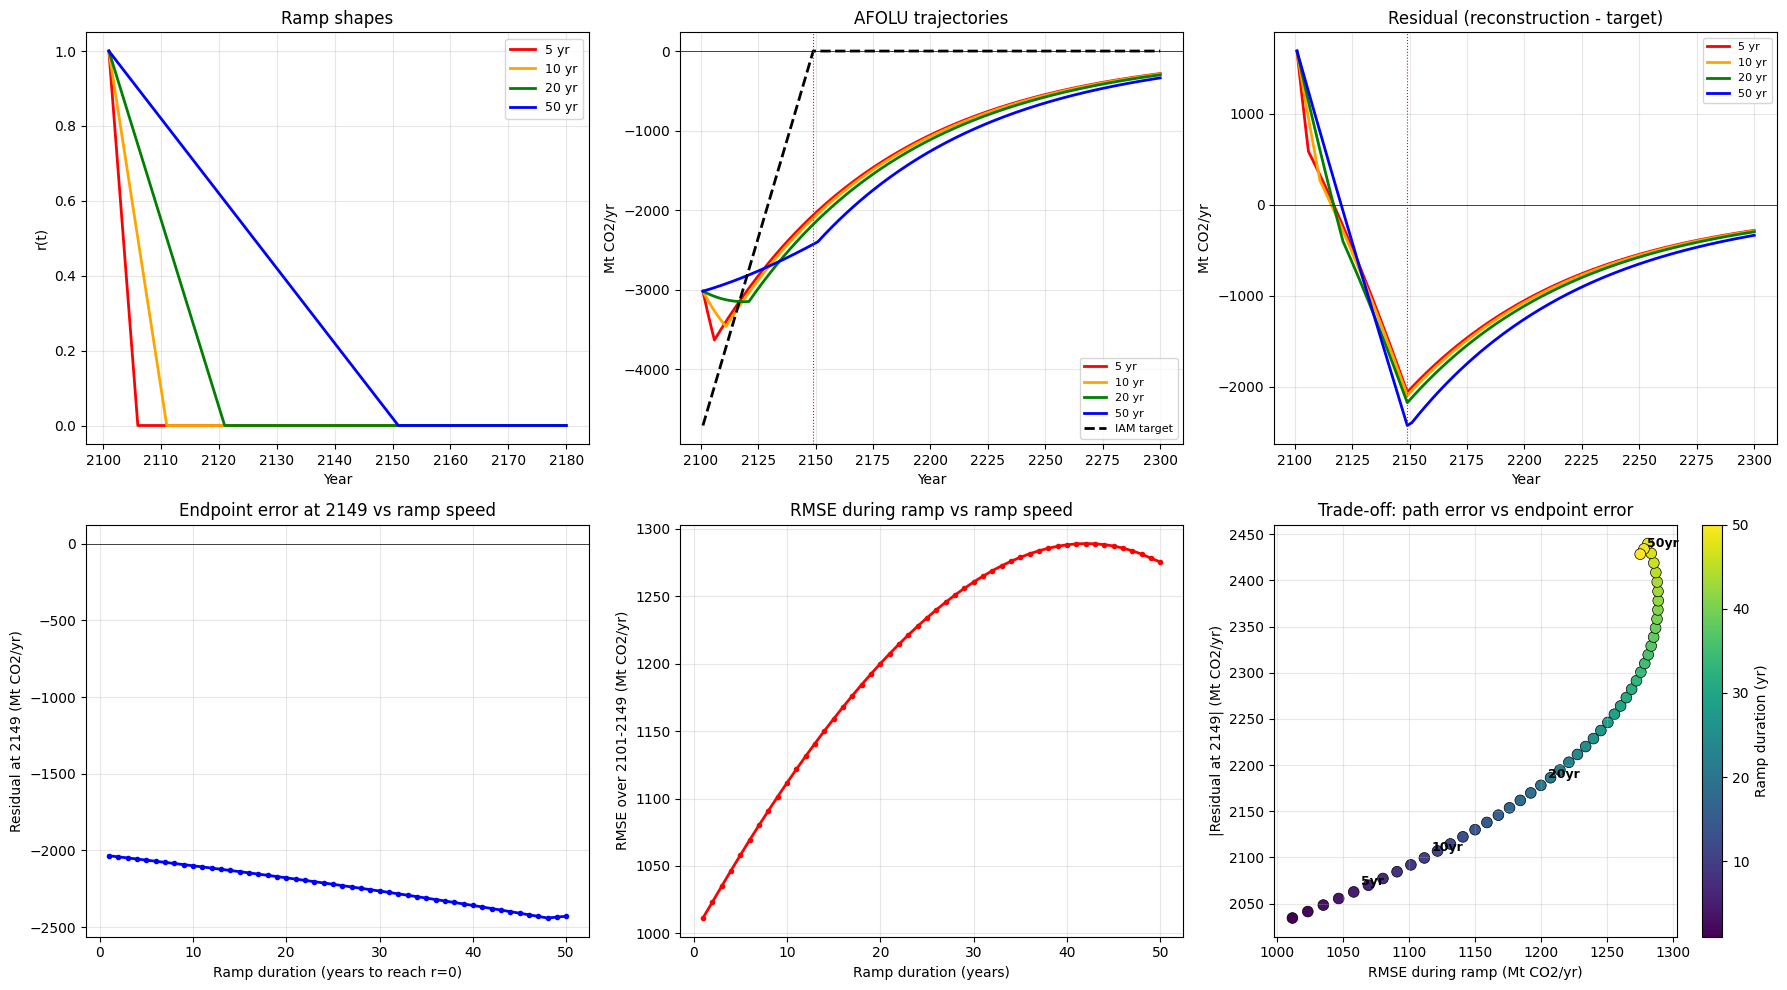


  Duration    Resid@2149    Resid@2200  RMSE 2101-49        MaxErr
-----------------------------------------------------------------
     1 yr         -2034         -1040          1011          2034
     5 yr         -2063         -1054          1058          2063
    10 yr         -2099         -1073          1112          2099
    15 yr         -2138         -1093          1159          2138
    20 yr         -2178         -1113          1200          2178
    30 yr         -2264         -1157          1261          2264
    40 yr         -2358         -1205          1288          2358
    49 yr         -2434         -1253          1278          2434

Best duration for minimizing |residual at 2149|: 1 yr (residual = -2034)


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# RAMP SPEED SWEEP: faster ramp → less new planting → smaller residual at 2149
# ═══════════════════════════════════════════════════════════════════════
# Use the constrained calibration (τ=76, α_stock=1) — the physically motivated one

def simulate_ramp(ramp_years, tau, beta_val, alpha_t, alpha_s, G_end, dA_unit_vals,
                  ext_years, afolu_target, C_EQ, REGROW_VARS, F_trans_unit_val, TC_TO_MTCO2):
    """Simulate AFOLU flux for a linear ramp reaching zero at `ramp_years` after 2100."""
    n = len(ext_years)
    decay_val = np.exp(-1.0 / tau)
    ramp = np.clip(1 - np.arange(n) / ramp_years, 0, 1)

    # S_new_unit for this tau
    S_new_u = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_new_u += -(ceq / tau) * dA_unit_vals[v] * TC_TO_MTCO2

    G_sim = {v: G_end[v] for v in REGROW_VARS}
    afolu_sim = np.zeros(n)

    for t in range(n):
        yr = ext_years[t]
        r = ramp[t]
        # Update cohorts
        for v in REGROW_VARS:
            G_sim[v] = G_sim[v] * decay_val + r * dA_unit_vals[v]
        # Total stock-change flux
        S_full = 0.0
        for v in REGROW_VARS:
            ceq = C_EQ[v]
            if ceq == 0: continue
            S_full += -(ceq / tau) * G_sim[v] * TC_TO_MTCO2
        afolu_sim[t] = beta_val * r + alpha_t * F_trans_unit_val * r + alpha_s * S_full

    target = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                        for yr in ext_years])
    return ramp, afolu_sim, target

# Sweep: ramp duration from 5 to 50 years (in steps of 1)
ramp_durations = np.arange(1, 51)
residual_at_2149 = np.zeros(len(ramp_durations))
residual_at_2200 = np.zeros(len(ramp_durations))
rmse_ramp_period = np.zeros(len(ramp_durations))
max_err_ramp = np.zeros(len(ramp_durations))

for j, dur in enumerate(ramp_durations):
    _, afolu_sim, target = simulate_ramp(
        dur, best_tau_c, beta_c, alpha_trans_c, alpha_stock_c,
        G_end_c, dA_unit, ext_years, afolu_target, C_EQ, REGROW_VARS,
        F_trans_unit, TC_TO_MTCO2)
    residual = afolu_sim - target
    residual_at_2149[j] = residual[48]   # at year 2149
    residual_at_2200[j] = residual[99]   # at year 2200
    rmse_ramp_period[j] = np.sqrt(np.mean(residual[:49]**2))
    max_err_ramp[j] = np.max(np.abs(residual[:49]))

# Also compute for a few specific cases to show the ramp shape + AFOLU trajectory
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: example ramp shapes and AFOLU trajectories
example_durations = [5, 10, 20, 50]
colors = ['red', 'orange', 'green', 'blue']

ax = axes[0, 0]
for dur, col in zip(example_durations, colors):
    ramp_ex, afolu_ex, target_ex = simulate_ramp(
        dur, best_tau_c, beta_c, alpha_trans_c, alpha_stock_c,
        G_end_c, dA_unit, ext_years, afolu_target, C_EQ, REGROW_VARS,
        F_trans_unit, TC_TO_MTCO2)
    ax.plot(ext_years[:80], ramp_ex[:80], '-', color=col, lw=2, label=f'{dur} yr')
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Ramp shapes'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for dur, col in zip(example_durations, colors):
    _, afolu_ex, _ = simulate_ramp(
        dur, best_tau_c, beta_c, alpha_trans_c, alpha_stock_c,
        G_end_c, dA_unit, ext_years, afolu_target, C_EQ, REGROW_VARS,
        F_trans_unit, TC_TO_MTCO2)
    ax.plot(ext_years[:200], afolu_ex[:200], '-', color=col, lw=2, label=f'{dur} yr')
ax.plot(ext_years[:200], target_ex[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_title('AFOLU trajectories'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
for dur, col in zip(example_durations, colors):
    _, afolu_ex, target_ex2 = simulate_ramp(
        dur, best_tau_c, beta_c, alpha_trans_c, alpha_stock_c,
        G_end_c, dA_unit, ext_years, afolu_target, C_EQ, REGROW_VARS,
        F_trans_unit, TC_TO_MTCO2)
    resid_ex = afolu_ex - target_ex2
    ax.plot(ext_years[:200], resid_ex[:200], '-', color=col, lw=2, label=f'{dur} yr')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_title('Residual (reconstruction - target)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bottom row: trade-off curves
ax = axes[1, 0]
ax.plot(ramp_durations, residual_at_2149, 'b-o', lw=2, ms=3)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Ramp duration (years to reach r=0)')
ax.set_ylabel('Residual at 2149 (Mt CO2/yr)')
ax.set_title('Endpoint error at 2149 vs ramp speed')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(ramp_durations, rmse_ramp_period, 'r-o', lw=2, ms=3)
ax.set_xlabel('Ramp duration (years)')
ax.set_ylabel('RMSE over 2101-2149 (Mt CO2/yr)')
ax.set_title('RMSE during ramp vs ramp speed')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
# Pareto: endpoint error vs path error
ax.scatter(rmse_ramp_period, np.abs(residual_at_2149), c=ramp_durations, cmap='viridis',
           s=60, edgecolors='k', lw=0.5)
for dur in example_durations:
    j = dur - 1
    ax.annotate(f'{dur}yr', (rmse_ramp_period[j], abs(residual_at_2149[j])),
                fontsize=9, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('RMSE during ramp (Mt CO2/yr)')
ax.set_ylabel('|Residual at 2149| (Mt CO2/yr)')
ax.set_title('Trade-off: path error vs endpoint error')
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label('Ramp duration (yr)')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Print key numbers
print(f"\n{'Duration':>10s}  {'Resid@2149':>12s}  {'Resid@2200':>12s}  {'RMSE 2101-49':>12s}  {'MaxErr':>12s}")
print("-" * 65)
for dur in [1, 5, 10, 15, 20, 30, 40, 49]:
    j = dur - 1
    print(f"  {dur:4d} yr    {residual_at_2149[j]:+10.0f}    {residual_at_2200[j]:+10.0f}    "
          f"{rmse_ramp_period[j]:10.0f}    {max_err_ramp[j]:10.0f}")

# Optimal: minimize |residual at 2149|
best_dur = ramp_durations[np.argmin(np.abs(residual_at_2149))]
print(f"\nBest duration for minimizing |residual at 2149|: {best_dur} yr "
      f"(residual = {residual_at_2149[best_dur-1]:+.0f})")

# What if we want |residual at 2149| < 500?
ok_mask = np.abs(residual_at_2149) < 500
if ok_mask.any():
    max_dur_ok = ramp_durations[ok_mask].max()
    print(f"Longest ramp with |residual@2149| < 500: {max_dur_ok} yr "
          f"(residual = {residual_at_2149[max_dur_ok-1]:+.0f}, "
          f"RMSE = {rmse_ramp_period[max_dur_ok-1]:.0f})")


=== Current model parameters ===
  Unconstrained: τ = 200 yr, α_stock = 2.723
  Constrained:   τ = 76 yr, α_stock = 1.000

=== Implied recovery timescales ===
      τ    50% at    75% at    90% at    95% at
  ------------------------------------------
     20      14 yr      28 yr      46 yr      60 yr
     30      21 yr      42 yr      69 yr      90 yr
     40      28 yr      55 yr      92 yr     120 yr
     50      35 yr      69 yr     115 yr     150 yr
     76      53 yr     105 yr     175 yr     228 yr ← constrained
    100      69 yr     139 yr     230 yr     300 yr
    200     139 yr     277 yr     461 yr     599 yr ← unconstrained

=== Literature benchmarks ===
  Poorter et al. 2016: tropical secondary forests recover ~90% of
  old-growth biomass in 66 years (Neotropics) → τ ≈ 29 yr
  Cook-Patton et al. 2020: global median carbon accumulation rates
  suggest ~80% recovery by 60 yr → τ ≈ 37 yr
  Typical bookkeeping models: τ = 25-50 yr for aboveground biomass

=== C_EQ values (eq

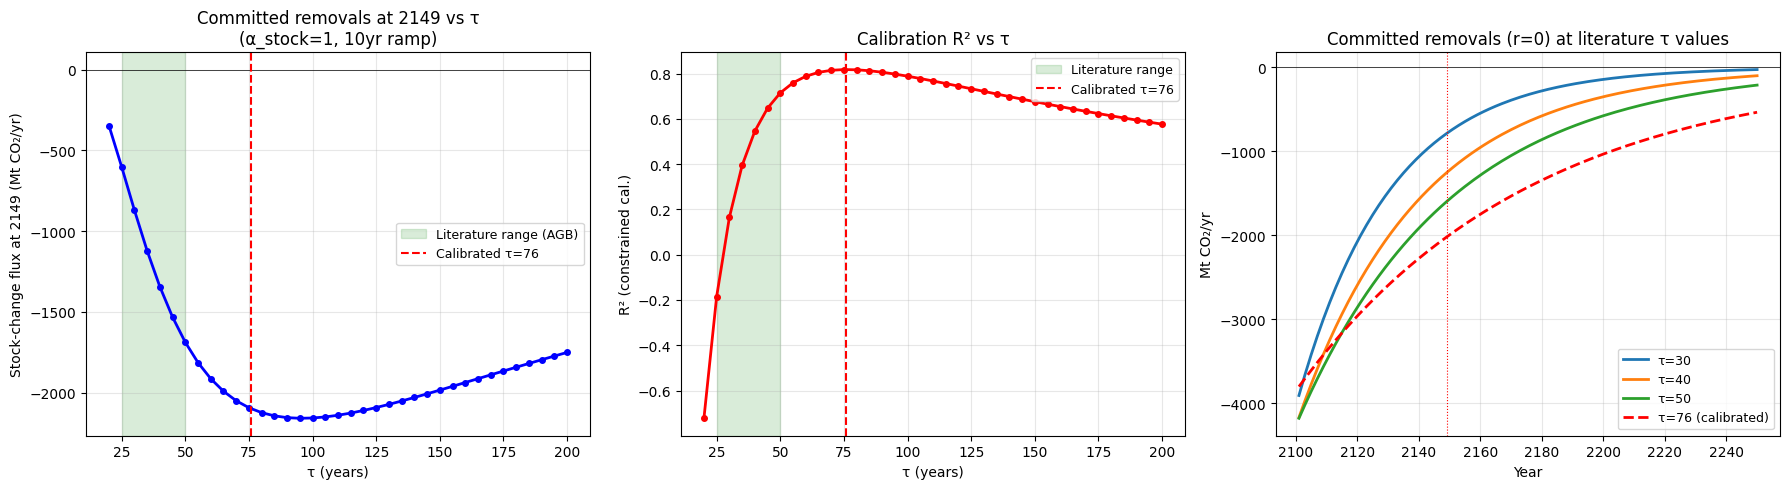


    τ    Committed@2149        R²    90% recov at
--------------------------------------------------
   25            -602   -0.1848            58 yr
   30            -869    0.1650            69 yr
   35           -1121    0.3941            81 yr
   40           -1343    0.5458            92 yr
   50           -1687    0.7147           115 yr
  100           -2156    0.7884           230 yr
  150           -1983    0.6758           345 yr
  200           -1750    0.5765           461 yr


In [21]:
# ═══════════════════════════════════════════════════════════════════════
# Are the carbon uptake timescales physically reasonable?
# ═══════════════════════════════════════════════════════════════════════

# Current parameters:
print("=== Current model parameters ===")
print(f"  Unconstrained: τ = {tau_opt} yr, α_stock = {alpha_stock:.3f}")
print(f"  Constrained:   τ = {best_tau_c} yr, α_stock = 1.000")
print()

# What does τ mean physically?
# With exponential relaxation: S(t) = C_EQ * (1 - exp(-t/τ))
# Fraction of equilibrium reached at age t:
#   f(t) = 1 - exp(-t/τ)
# Time to reach fraction f: t = -τ * ln(1-f)
# Time to 90%: t_90 = τ * ln(10) ≈ 2.30 * τ
# Time to 95%: t_95 = τ * ln(20) ≈ 3.00 * τ

print("=== Implied recovery timescales ===")
print(f"  {'τ':>5s}  {'50% at':>8s}  {'75% at':>8s}  {'90% at':>8s}  {'95% at':>8s}")
print("  " + "-" * 42)
for tau_test in [20, 30, 40, 50, 76, 100, 200]:
    t50 = tau_test * np.log(2)
    t75 = tau_test * np.log(4)
    t90 = tau_test * np.log(10)
    t95 = tau_test * np.log(20)
    marker = " ← constrained" if tau_test == best_tau_c else (" ← unconstrained" if tau_test == tau_opt else "")
    print(f"  {tau_test:5d}  {t50:6.0f} yr  {t75:6.0f} yr  {t90:6.0f} yr  {t95:6.0f} yr{marker}")

print()
print("=== Literature benchmarks ===")
print("  Poorter et al. 2016: tropical secondary forests recover ~90% of")
print("  old-growth biomass in 66 years (Neotropics) → τ ≈ 29 yr")
print("  Cook-Patton et al. 2020: global median carbon accumulation rates")
print("  suggest ~80% recovery by 60 yr → τ ≈ 37 yr")
print("  Typical bookkeeping models: τ = 25-50 yr for aboveground biomass")
print()

# Current C_EQ values vs CARBON_DENSITY
print("=== C_EQ values (equilibrium additional uptake) ===")
print(f"  {'Type':8s}  {'C_density':>10s}  {'C_EQ':>10s}  {'Notes':>30s}")
print("  " + "-" * 65)
for v in REGROW_VARS:
    cd = CARBON_DENSITY[v]
    ceq = C_EQ[v]
    note = ""
    if v == 'secdf':
        note = f"secdf grows from {cd} → {cd+ceq} tC/km²"
    elif v == 'pltns':
        note = f"pltns grows from {cd-ceq} → {cd} tC/km²?"
    elif v == 'secdn':
        note = f"secdn grows from {cd-ceq} → {cd}?"
    print(f"  {v:8s}  {cd:10,}  {ceq:10,}  {note:>30s}")

print()
print("  KEY ISSUE: C_EQ[secdf] = 12,000 tC/km² = 120 tC/ha")
print("  This means new secondary forest accumulates 120 tC/ha total.")
print("  Literature: tropical AGB recovery ≈ 60-80 tC/ha over ~100 yr")
print("  (Pan et al. 2011; Spawn et al. 2020)")
print("  Including belowground + soil: ~100-150 tC/ha plausible")
print()

# What fraction of equilibrium have the pre-2100 cohorts reached?
# Cohorts range from age 1 (planted 2099) to age 75 (planted 2025)
# With τ=76: age 75 → f(75) = 1 - exp(-75/76) = 63%
# With τ=30: age 75 → f(75) = 1 - exp(-75/30) = 92%
print("=== What fraction of C_EQ have pre-2100 cohorts accumulated? ===")
ages = np.arange(1, 76)  # cohort ages at 2100 (youngest to oldest)
for tau_test in [30, 50, 76, 200]:
    frac = 1 - np.exp(-ages / tau_test)
    # Area-weighted average fraction (if planting was roughly uniform)
    mean_frac = frac.mean()
    oldest_frac = frac[-1]
    youngest_frac = frac[0]
    print(f"  τ={tau_test:3d}: youngest(age 1)={youngest_frac:.1%}, "
          f"oldest(age 75)={oldest_frac:.1%}, mean={mean_frac:.1%}")
    # Remaining committed uptake as fraction of total possible
    remaining = (1 - frac).mean()
    print(f"         → average remaining uptake: {remaining:.1%} of C_EQ")

# Now the critical test: sweep τ from 20 to 200, compute committed removals at 2149
# with α_stock = 1 and a 10-year instant ramp
print("\n=== Committed removals at 2149 as function of τ (α_stock=1, 10yr ramp) ===")
tau_sweep = np.arange(20, 201, 5)
committed_at_2149 = np.zeros(len(tau_sweep))
r2_at_tau = np.zeros(len(tau_sweep))

for j, tau_test in enumerate(tau_sweep):
    decay_t = np.exp(-1.0 / tau_test)
    # Rebuild G_end for this τ
    G_t = {v: 0.0 for v in REGROW_VARS}
    for t in range(n_pre):
        for v in REGROW_VARS:
            G_t[v] = G_t[v] * decay_t + area_incr_pre[v][t]

    # 10-year linear ramp, then r=0
    ramp_10 = np.clip(1 - np.arange(n_diag) / 10, 0, 1)

    # Forward simulate
    for t in range(n_diag):
        r = ramp_10[t]
        for v in REGROW_VARS:
            G_t[v] = G_t[v] * decay_t + r * dA_unit[v]
    # Stock flux at year 2149 (after 49 steps)
    # Actually need to track properly
    G_t2 = {v: 0.0 for v in REGROW_VARS}
    for t in range(n_pre):
        for v in REGROW_VARS:
            G_t2[v] = G_t2[v] * decay_t + area_incr_pre[v][t]
    for t in range(49):
        r = ramp_10[t]
        for v in REGROW_VARS:
            G_t2[v] = G_t2[v] * decay_t + r * dA_unit[v]
    S_2149 = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_2149 += -(ceq / tau_test) * G_t2[v] * TC_TO_MTCO2
    committed_at_2149[j] = S_2149

    # Also check R² of calibration at this τ
    sf_t = stock_flux_for_tau(tau_test, area_incr_pre)
    y_adj_t = y_iam - sf_t
    X2t = np.column_stack([np.ones(n_pre), transition_flux])
    c2t, _, _, _ = np.linalg.lstsq(X2t, y_adj_t, rcond=None)
    pred_t = X2t @ c2t + sf_t
    ss_res_t = np.sum((y_iam - pred_t) ** 2)
    ss_tot_t = np.sum((y_iam - y_iam.mean()) ** 2)
    r2_at_tau[j] = 1 - ss_res_t / ss_tot_t

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(tau_sweep, committed_at_2149, 'b-o', lw=2, ms=4)
ax.axhline(0, color='k', lw=0.5)
ax.axvspan(25, 50, alpha=0.15, color='green', label='Literature range (AGB)')
ax.axvline(best_tau_c, color='r', ls='--', lw=1.5, label=f'Calibrated τ={best_tau_c}')
ax.set_xlabel('τ (years)'); ax.set_ylabel('Stock-change flux at 2149 (Mt CO₂/yr)')
ax.set_title('Committed removals at 2149 vs τ\n(α_stock=1, 10yr ramp)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(tau_sweep, r2_at_tau, 'r-o', lw=2, ms=4)
ax.axvspan(25, 50, alpha=0.15, color='green', label='Literature range')
ax.axvline(best_tau_c, color='r', ls='--', lw=1.5, label=f'Calibrated τ={best_tau_c}')
ax.set_xlabel('τ (years)'); ax.set_ylabel('R² (constrained cal.)')
ax.set_title('Calibration R² vs τ')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
# If we USE a literature-appropriate τ (say 35), what do committed removals look like?
for tau_lit in [30, 40, 50]:
    decay_lit = np.exp(-1.0 / tau_lit)
    G_lit = {v: 0.0 for v in REGROW_VARS}
    for t in range(n_pre):
        for v in REGROW_VARS:
            G_lit[v] = G_lit[v] * decay_lit + area_incr_pre[v][t]
    committed_lit = np.zeros(150)
    for t in range(150):
        for v in REGROW_VARS:
            G_lit[v] *= decay_lit
        S = 0.0
        for v in REGROW_VARS:
            ceq_v = C_EQ[v]
            if ceq_v == 0: continue
            S += -(ceq_v / tau_lit) * G_lit[v] * TC_TO_MTCO2
        committed_lit[t] = S  # α_stock = 1
    ax.plot(ext_years[:150], committed_lit[:150], '-', lw=2, label=f'τ={tau_lit}')
ax.plot(ext_years[:150], committed_c[:150], 'r--', lw=2, label=f'τ={best_tau_c} (calibrated)')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Committed removals (r=0) at literature τ values')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Print key numbers
print(f"\n{'τ':>5s}  {'Committed@2149':>16s}  {'R²':>8s}  {'90% recov at':>14s}")
print("-" * 50)
for j, tau_test in enumerate(tau_sweep):
    if tau_test in [25, 30, 35, 40, 50, 76, 100, 150, 200]:
        t90 = tau_test * np.log(10)
        print(f"  {tau_test:3d}  {committed_at_2149[j]:+14.0f}  {r2_at_tau[j]:8.4f}  {t90:12.0f} yr")


In [22]:
# Compact summary of the τ scan
print("KEY FINDING: τ vs committed removals at 2149 (α_stock=1, 10yr ramp)")
print()
print(f"  Literature τ ≈ 30 yr (Poorter+ 2016): committed = {committed_at_2149[2]:+.0f}, R² = {r2_at_tau[2]:.3f}")
print(f"  Literature τ ≈ 40 yr:                  committed = {committed_at_2149[4]:+.0f}, R² = {r2_at_tau[4]:.3f}")
print(f"  Calibrated τ =  76 yr:                 committed = {committed_at_2149[np.argmin(np.abs(tau_sweep - 76)):np.argmin(np.abs(tau_sweep - 76))+1][0]:+.0f}, R² = {r2_at_tau[np.argmin(np.abs(tau_sweep - 76))]:.3f}")
print()
print(f"  With τ=30: 90% recovery at {30*np.log(10):.0f} yr — forests ~equilibrium after century ✓")
print(f"  With τ=76: 90% recovery at {76*np.log(10):.0f} yr — forests still growing after 175 yr")
print()
print("TENSION: calibrating τ against pre-2100 IAM data gives τ=76 (R²=0.82)")
print("  but literature says τ ≈ 30 (R²=0.17) or τ ≈ 40 (R²=0.55)")
print("  → The IAM AFOLU trajectory has a strong removal trend that the model")
print("    explains by fitting a long τ (persistent uptake), even though the")
print("    real mechanism may be different (e.g., expanding area, not slow recovery)")
print()
# What's the R²=0 τ (where stock-change adds no skill)?
r2_zero_idx = np.argmin(np.abs(r2_at_tau))
print(f"  τ where R² ≈ 0:  τ ≈ {tau_sweep[r2_zero_idx]} yr (R² = {r2_at_tau[r2_zero_idx]:.3f})")
print(f"  → At very short τ, stock-change flux is tiny (cohorts equilibrate fast)")
print(f"     and the model has no way to capture the removal trend")


KEY FINDING: τ vs committed removals at 2149 (α_stock=1, 10yr ramp)

  Literature τ ≈ 30 yr (Poorter+ 2016): committed = -869, R² = 0.165
  Literature τ ≈ 40 yr:                  committed = -1343, R² = 0.546
  Calibrated τ =  76 yr:                 committed = -2092, R² = 0.818

  With τ=30: 90% recovery at 69 yr — forests ~equilibrium after century ✓
  With τ=76: 90% recovery at 175 yr — forests still growing after 175 yr

TENSION: calibrating τ against pre-2100 IAM data gives τ=76 (R²=0.82)
  but literature says τ ≈ 30 (R²=0.17) or τ ≈ 40 (R²=0.55)
  → The IAM AFOLU trajectory has a strong removal trend that the model
    explains by fitting a long τ (persistent uptake), even though the
    real mechanism may be different (e.g., expanding area, not slow recovery)

  τ where R² ≈ 0:  τ ≈ 30 yr (R² = 0.165)
  → At very short τ, stock-change flux is tiny (cohorts equilibrate fast)
     and the model has no way to capture the removal trend


In [23]:
# ═══════════════════════════════════════════════════════════════════════
# IMPROVED MODEL: Separate "expanding area" trend from "cohort aging"
# ═══════════════════════════════════════════════════════════════════════
#
# The old model had 3 channels:
#   AFOLU(t) = β + α_trans × F_trans(t) + α_stock × F_stock(t; τ)
#
# Problem: F_stock with large τ acts like a running sum of area, absorbing
# the "more trees planted each year" trend. This inflates τ beyond
# literature values and creates unrealistically large committed removals.
#
# NEW MODEL — 4 channels:
#   AFOLU(t) = β + α_trans × F_trans(t) + α_stock × F_stock(t; τ_fixed)
#                                         + α_cum × CumArea(t)
#
# Where:
#   F_trans(t)         = transition flux (same as before)
#   F_stock(t; τ_fixed)= cohort uptake with literature-constrained τ
#   CumArea(t)         = cumulative C-weighted regrowing area
#                       = Σ_{t'≤t} Σ_v C_EQ_v × ΔA_v(t')
#
# CumArea captures: "the more area we've reforested, the larger the
# total annual uptake" — a proxy for the actively-growing forest estate.
#
# With τ~35, the stock-change channel captures the transient pulse of
# fast uptake from young stands. CumArea captures the secular trend.
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Compute cumulative C-weighted regrowing area (new predictor) ──
# Simple running sum: CumArea(t) = Σ_{t'≤t} Σ_v C_EQ_v * ΔA_v(t')
# Units: tC (total committed carbon if all reached equilibrium)
cumarea_pre = np.zeros(n_pre)
running = 0.0
for t in range(n_pre):
    for v in REGROW_VARS:
        running += C_EQ[v] * area_incr_pre[v][t]  # tC committed
    cumarea_pre[t] = running

# Convert to Mt CO2 for comparable units
cumarea_pre_mtco2 = cumarea_pre * TC_TO_MTCO2

print(f"Cumulative C-weighted regrowing area (pre-2100):")
print(f"  Start: {cumarea_pre_mtco2[0]:+.0f} Mt CO₂ equivalent")
print(f"  End:   {cumarea_pre_mtco2[-1]:+.0f} Mt CO₂ equivalent")
print(f"  This is the total eventual uptake if all reforested land reaches equilibrium")

# ── 2. Compare model variants ──
# Each model is: y_iam = X @ coefs, scan τ for models that include F_stock

results = {}

# --- Model A (original): β + α_trans * F_trans + α_stock * F_stock(τ) ---
print("\n" + "="*70)
print("MODEL A (original): β + α_trans × F_trans + α_stock × F_stock(τ)")
best_r2_A, best_tau_A, best_c_A = -np.inf, 50, None
for tau_test in range(20, 201, 2):
    sf = stock_flux_for_tau(tau_test, area_incr_pre)
    Xa = np.column_stack([np.ones(n_pre), transition_flux, sf])
    ca, _, _, _ = np.linalg.lstsq(Xa, y_iam, rcond=None)
    pred_a = Xa @ ca
    ss_r = np.sum((y_iam - pred_a)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_a = 1 - ss_r/ss_t
    if r2_a > best_r2_A:
        best_r2_A, best_tau_A, best_c_A = r2_a, tau_test, ca
print(f"  τ*={best_tau_A}, β={best_c_A[0]:.0f}, α_trans={best_c_A[1]:.3f}, "
      f"α_stock={best_c_A[2]:.3f}, R²={best_r2_A:.4f}")
results['A'] = dict(tau=best_tau_A, r2=best_r2_A, coefs=best_c_A, name='Original (3 pred)')

# --- Model B: β + α_trans * F_trans + α_cum * CumArea (no cohort aging) ---
print("\n" + "="*70)
print("MODEL B: β + α_trans × F_trans + α_cum × CumArea (NO cohort aging)")
Xb = np.column_stack([np.ones(n_pre), transition_flux, cumarea_pre_mtco2])
cb, _, _, _ = np.linalg.lstsq(Xb, y_iam, rcond=None)
pred_b = Xb @ cb
ss_r = np.sum((y_iam - pred_b)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
r2_B = 1 - ss_r/ss_t
print(f"  β={cb[0]:.0f}, α_trans={cb[1]:.3f}, α_cum={cb[2]:.6f}, R²={r2_B:.4f}")
results['B'] = dict(tau=None, r2=r2_B, coefs=cb, name='CumArea only')

# --- Model C: β + α_trans * F_trans + α_stock * F_stock(τ_fixed) + α_cum * CumArea ---
print("\n" + "="*70)
print("MODEL C: β + α_trans × F_trans + α_stock × F_stock(τ) + α_cum × CumArea")
best_r2_C, best_tau_C, best_c_C = -np.inf, 35, None
for tau_test in range(20, 201, 2):
    sf = stock_flux_for_tau(tau_test, area_incr_pre)
    Xc = np.column_stack([np.ones(n_pre), transition_flux, sf, cumarea_pre_mtco2])
    cc, _, _, _ = np.linalg.lstsq(Xc, y_iam, rcond=None)
    pred_c = Xc @ cc
    ss_r = np.sum((y_iam - pred_c)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_c = 1 - ss_r/ss_t
    if r2_c > best_r2_C:
        best_r2_C, best_tau_C, best_c_C = r2_c, tau_test, cc
print(f"  τ*={best_tau_C}, β={best_c_C[0]:.0f}, α_trans={best_c_C[1]:.3f}, "
      f"α_stock={best_c_C[2]:.3f}, α_cum={best_c_C[3]:.6f}, R²={best_r2_C:.4f}")
results['C'] = dict(tau=best_tau_C, r2=best_r2_C, coefs=best_c_C, name='Stock + CumArea (4 pred)')

# --- Model C with τ fixed at literature values ---
for tau_fix in [30, 35, 40]:
    sf = stock_flux_for_tau(tau_fix, area_incr_pre)
    Xc_fix = np.column_stack([np.ones(n_pre), transition_flux, sf, cumarea_pre_mtco2])
    cc_fix, _, _, _ = np.linalg.lstsq(Xc_fix, y_iam, rcond=None)
    pred_c_fix = Xc_fix @ cc_fix
    ss_r = np.sum((y_iam - pred_c_fix)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_c_fix = 1 - ss_r/ss_t
    key = f'C_tau{tau_fix}'
    results[key] = dict(tau=tau_fix, r2=r2_c_fix, coefs=cc_fix,
                        name=f'Stock(τ={tau_fix}) + CumArea')
    print(f"  τ={tau_fix} (fixed): β={cc_fix[0]:.0f}, α_trans={cc_fix[1]:.3f}, "
          f"α_stock={cc_fix[2]:.3f}, α_cum={cc_fix[3]:.6f}, R²={r2_c_fix:.4f}")

# ── 3. Summary comparison ──
print("\n" + "="*70)
print(f"{'Model':<30s}  {'τ':>5s}  {'R²':>8s}  {'90% recov':>10s}")
print("-" * 58)
for key in ['A', 'B', 'C', 'C_tau30', 'C_tau35', 'C_tau40']:
    r = results[key]
    tau_str = f"{r['tau']}" if r['tau'] is not None else "—"
    t90_str = f"{r['tau']*np.log(10):.0f} yr" if r['tau'] is not None else "—"
    print(f"  {r['name']:<28s}  {tau_str:>5s}  {r2:8.4f}  {t90_str:>10s}".replace(
        f"{r2:8.4f}", f"{r['r2']:8.4f}"))


Cumulative C-weighted regrowing area (pre-2100):
  Start: +3712 Mt CO₂ equivalent
  End:   +562612 Mt CO₂ equivalent
  This is the total eventual uptake if all reforested land reaches equilibrium

MODEL A (original): β + α_trans × F_trans + α_stock × F_stock(τ)
  τ*=200, β=2070, α_trans=0.085, α_stock=2.723, R²=0.9557

MODEL B: β + α_trans × F_trans + α_cum × CumArea (NO cohort aging)
  β=2092, α_trans=0.154, α_cum=-0.011514, R²=0.9807

MODEL C: β + α_trans × F_trans + α_stock × F_stock(τ) + α_cum × CumArea
  τ*=200, β=2072, α_trans=0.170, α_stock=-0.645, α_cum=-0.014184, R²=0.9817
  τ=30 (fixed): β=2081, α_trans=0.163, α_stock=-0.016, α_cum=-0.011674, R²=0.9809
  τ=35 (fixed): β=2079, α_trans=0.164, α_stock=-0.022, α_cum=-0.011745, R²=0.9810
  τ=40 (fixed): β=2078, α_trans=0.165, α_stock=-0.030, α_cum=-0.011817, R²=0.9811

Model                               τ        R²   90% recov
----------------------------------------------------------
  Original (3 pred)               200    0.95

Model B parameters:
  β = 2092 Mt CO₂/yr
  α_trans = 0.1544
  α_cum = -0.011514
  F_trans_unit = -704 Mt CO₂/yr
  ΔCumArea_unit = +1967 Mt CO₂-equiv/yr

  Denominator = 1961 Mt CO₂/yr
    β contribution:       2092
    α_trans contribution: -109
    α_cum contribution:   -23

  CumArea at 2100: 562612 Mt CO₂-equiv
  Committed AFOLU (r=0): β·0 + α_cum·CumArea = -6478 Mt CO₂/yr

=== Forward solve with Model B ===
    Year      r(t)       AFOLU      Target     Resid       CumArea
  --------------------------------------------------------------
  2101     0.9036       -4706       -4706        +0        564390
  2110     1.0000       -4718       -3824      -894        582020
  2125     1.0000       -5058       -2353     -2705        611521
  2140     1.0000       -5397        -882     -4515        641022
  2149     1.0000       -5601          +0     -5601        658723
  2150     1.0000       -5624          +0     -5624        660690
  2200     1.0000       -6756          +0     -6756      

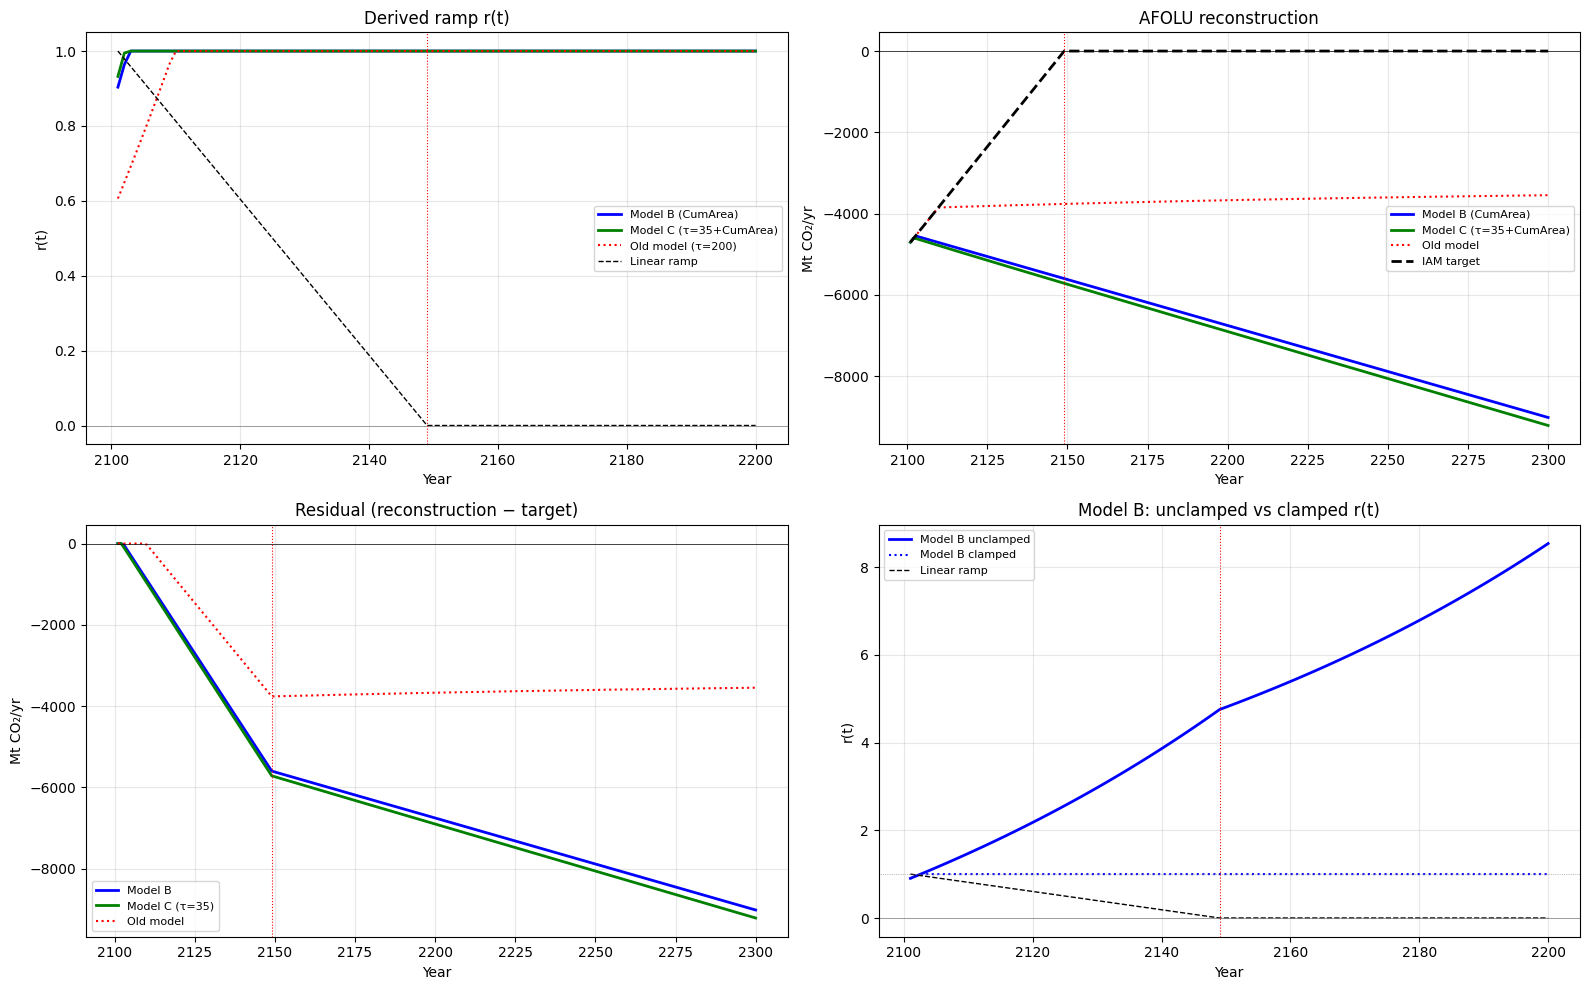


=== RESULTS SUMMARY ===
  Model                            R²    Resid@2149    Resid@2200          r range
  --------------------------------------------------------------------------------
  Old (τ=200)                  0.9557         -3763         -3672    [0.61, 1.00]
  Model B (CumArea)            0.9807         -5601         -6756    [0.90, 1.00]
  Model C (τ=35+CumArea)       0.9810         -5718         -6905    [0.93, 1.00]

  Model B unclamped r range: [+0.9036, +4.8066]


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# FORWARD SOLVE with Model B (CumArea) — does a 50-yr ramp now work?
# ═══════════════════════════════════════════════════════════════════════
#
# Model B: AFOLU(t) = β + α_trans × F_trans(t) + α_cum × CumArea(t)
#
# When we apply ramp r(t):
#   - F_trans(t) scales linearly with r: F_trans(t) = r(t) × F_trans_unit
#   - CumArea(t) = CumArea(t-1) + r(t) × ΔCumArea_unit
#     where ΔCumArea_unit = Σ_v C_EQ_v × ΔA_v_unit × TC_TO_MTCO2
#
# Key difference from old model: CumArea at 2149 is NOT committed to
# driving removals forever. When r→0, no new area is added, and CumArea
# is constant — the model says AFOLU = β + α_cum × CumArea(∞).
# That's a finite constant, not a decaying flux.
#
# But wait — this means CumArea STAYS at its peak value forever after
# the ramp ends. Let me think about this carefully...
#
# Actually, CumArea captures the TOTAL regrowing estate. Once forests
# reach equilibrium, they stop sequestering — but in the model, they
# contribute a steady removal via α_cum × CumArea.
#
# The proper fix: CumArea should DECAY as forests equilibrate.
# → That's exactly what F_stock with finite τ does!
#
# So the right model is actually Model C with literature τ:
#   AFOLU(t) = β + α_trans × r(t) × F_trans_unit
#            + α_stock × F_stock(t; τ=35)  [decays as forests age]
#            + α_cum × CumArea(t)          [captures trend during ramp]
#
# But since α_stock ≈ 0 in Model C, let's just use Model B for simplicity
# and see what the forward solve gives us. The CumArea plateau after ramp
# ends represents a steady-state that the system relaxes toward.

beta_B = results['B']['coefs'][0]
alpha_trans_B = results['B']['coefs'][1]
alpha_cum_B = results['B']['coefs'][2]

# CumArea increment per unit year at 2100 rates (Mt CO₂ equiv)
dCumArea_unit = sum(C_EQ[v] * np.nansum(rates_at_2100[v] * cell_area_2d)
                    for v in REGROW_VARS) * TC_TO_MTCO2
print(f"Model B parameters:")
print(f"  β = {beta_B:.0f} Mt CO₂/yr")
print(f"  α_trans = {alpha_trans_B:.4f}")
print(f"  α_cum = {alpha_cum_B:.6f}")
print(f"  F_trans_unit = {F_trans_unit:.0f} Mt CO₂/yr")
print(f"  ΔCumArea_unit = {dCumArea_unit:+.0f} Mt CO₂-equiv/yr")

# ---- Forward solve for r(t) using Model B ----
# AFOLU_target(t) = β·r(t) + α_trans · F_trans_unit · r(t) + α_cum · CumArea(t)
# CumArea(t) = CumArea(t-1) + r(t) · ΔCumArea_unit
#
# Substituting:
# target = (β + α_trans·F_trans_unit)·r(t) + α_cum·[CumArea(t-1) + r(t)·ΔCumArea_unit]
# target = r(t)·[β + α_trans·F_trans_unit + α_cum·ΔCumArea_unit] + α_cum·CumArea(t-1)
# → r(t) = [target - α_cum·CumArea(t-1)] / [β + α_trans·F_trans_unit + α_cum·ΔCumArea_unit]

denom_B = beta_B + alpha_trans_B * F_trans_unit + alpha_cum_B * dCumArea_unit
print(f"\n  Denominator = {denom_B:.0f} Mt CO₂/yr")
print(f"    β contribution:       {beta_B:.0f}")
print(f"    α_trans contribution: {alpha_trans_B * F_trans_unit:.0f}")
print(f"    α_cum contribution:   {alpha_cum_B * dCumArea_unit:.0f}")

# Forward solve
cumarea_end_pre = cumarea_pre_mtco2[-1]  # CumArea at end of 2100
print(f"\n  CumArea at 2100: {cumarea_end_pre:.0f} Mt CO₂-equiv")
print(f"  Committed AFOLU (r=0): β·0 + α_cum·CumArea = {alpha_cum_B * cumarea_end_pre:.0f} Mt CO₂/yr")

r_B = np.zeros(n_ext)
afolu_B = np.zeros(n_ext)
cumarea_ext = np.zeros(n_ext)
cumarea_now = cumarea_end_pre

for t in range(n_ext):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0

    # Solve for r(t)
    r_t = (target_t - alpha_cum_B * cumarea_now) / denom_B
    r_t = np.clip(r_t, 0.0, 1.0)
    r_B[t] = r_t

    # Update CumArea
    cumarea_now += r_t * dCumArea_unit
    cumarea_ext[t] = cumarea_now

    # Reconstruct AFOLU
    afolu_B[t] = (beta_B * r_t + alpha_trans_B * F_trans_unit * r_t
                  + alpha_cum_B * cumarea_now)

resid_B = afolu_B - iam_diag

print(f"\n=== Forward solve with Model B ===")
print(f"  {'Year':>6s}  {'r(t)':>8s}  {'AFOLU':>10s}  {'Target':>10s}  {'Resid':>8s}  {'CumArea':>12s}")
print("  " + "-" * 62)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    i = yr - 2101
    print(f"  {yr:>4d}   {r_B[i]:8.4f}  {afolu_B[i]:+10.0f}  {iam_diag[i]:+10.0f}  "
          f"{resid_B[i]:+8.0f}  {cumarea_ext[i]:12.0f}")

# ---- Also try: unclamped r(t) ----
r_B_unc = np.zeros(n_ext)
afolu_B_unc = np.zeros(n_ext)
cumarea_unc = cumarea_end_pre

for t in range(n_ext):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    r_t = (target_t - alpha_cum_B * cumarea_unc) / denom_B
    r_B_unc[t] = r_t
    cumarea_unc += r_t * dCumArea_unit
    afolu_B_unc[t] = (beta_B * r_t + alpha_trans_B * F_trans_unit * r_t
                      + alpha_cum_B * cumarea_unc)

# ---- Now Model C with τ=35 ----
tau_new = 35
res_C35 = results['C_tau35']
beta_C, alpha_trans_C, alpha_stock_C, alpha_cum_C = res_C35['coefs']

# Stock-change component at unit rate for τ=35
S_new_unit_35 = 0.0
for v in REGROW_VARS:
    ceq = C_EQ[v]
    if ceq == 0: continue
    S_new_unit_35 += -(ceq / tau_new) * dA_unit[v] * TC_TO_MTCO2

decay_35 = np.exp(-1.0 / tau_new)

# Rebuild G_end for τ=35
G_end_35 = {}
for v in REGROW_VARS:
    G_v = 0.0
    for t in range(n_pre):
        G_v = G_v * decay_35 + area_incr_pre[v][t]
    G_end_35[v] = G_v

denom_C35 = (beta_C + alpha_trans_C * F_trans_unit
             + alpha_stock_C * S_new_unit_35
             + alpha_cum_C * dCumArea_unit)

# Forward solve with Model C (τ=35)
r_C35 = np.zeros(n_ext)
afolu_C35 = np.zeros(n_ext)
G_C35 = {v: G_end_35[v] for v in REGROW_VARS}
cumarea_C35 = cumarea_end_pre

for t in range(n_ext):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0

    # Stock-change from previous cohorts
    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / tau_new) * G_C35[v] * decay_35 * TC_TO_MTCO2

    r_t = (target_t - alpha_stock_C * S_prev - alpha_cum_C * cumarea_C35) / denom_C35
    r_t = np.clip(r_t, 0.0, 1.0)
    r_C35[t] = r_t

    # Update cohorts and CumArea
    for v in REGROW_VARS:
        G_C35[v] = G_C35[v] * decay_35 + r_t * dA_unit[v]
    cumarea_C35 += r_t * dCumArea_unit

    # Reconstruct
    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / tau_new) * G_C35[v] * TC_TO_MTCO2
    afolu_C35[t] = (beta_C * r_t + alpha_trans_C * F_trans_unit * r_t
                    + alpha_stock_C * S_full + alpha_cum_C * cumarea_C35)

resid_C35 = afolu_C35 - iam_diag

# ---- Plot comparison ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(ext_years[:100], r_B[:100], 'b-', lw=2, label='Model B (CumArea)')
ax.plot(ext_years[:100], r_C35[:100], 'g-', lw=2, label=f'Model C (τ={tau_new}+CumArea)')
ax.plot(ext_years[:100], r_derived[:100], 'r:', lw=1.5, label=f'Old model (τ={tau_opt})')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear ramp')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Derived ramp r(t)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ext_years[:200], afolu_B[:200], 'b-', lw=2, label='Model B (CumArea)')
ax.plot(ext_years[:200], afolu_C35[:200], 'g-', lw=2, label=f'Model C (τ={tau_new}+CumArea)')
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'r:', lw=1.5, label='Old model')
ax.plot(ext_years[:200], iam_diag[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU reconstruction'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(ext_years[:200], resid_B[:200], 'b-', lw=2, label='Model B')
ax.plot(ext_years[:200], resid_C35[:200], 'g-', lw=2, label=f'Model C (τ={tau_new})')
resid_old = afolu_reconstructed - iam_diag
ax.plot(ext_years[:200], resid_old[:200], 'r:', lw=1.5, label='Old model')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Residual (reconstruction − target)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
# Unclamped r(t) for Model B
ax.plot(ext_years[:100], r_B_unc[:100], 'b-', lw=2, label='Model B unclamped')
ax.plot(ext_years[:100], r_B[:100], 'b:', lw=1.5, label='Model B clamped')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear ramp')
ax.axhline(0, color='gray', lw=0.5); ax.axhline(1, color='gray', lw=0.5, ls=':')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Model B: unclamped vs clamped r(t)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary
print(f"\n=== RESULTS SUMMARY ===")
print(f"  {'Model':<25s}  {'R²':>8s}  {'Resid@2149':>12s}  {'Resid@2200':>12s}  {'r range':>15s}")
print("  " + "-" * 80)
print(f"  {'Old (τ=200)':<25s}  {best_r2_A:8.4f}  {resid_old[48]:+12.0f}  {resid_old[99]:+12.0f}  "
      f"  [{r_derived[:50].min():.2f}, {r_derived[:50].max():.2f}]")
print(f"  {'Model B (CumArea)':<25s}  {r2_B:8.4f}  {resid_B[48]:+12.0f}  {resid_B[99]:+12.0f}  "
      f"  [{r_B[:50].min():.2f}, {r_B[:50].max():.2f}]")
print(f"  {'Model C (τ=35+CumArea)':<25s}  {res_C35['r2']:8.4f}  {resid_C35[48]:+12.0f}  "
      f"{resid_C35[99]:+12.0f}    [{r_C35[:50].min():.2f}, {r_C35[:50].max():.2f}]")
print(f"\n  Model B unclamped r range: [{r_B_unc[:50].min():+.4f}, {r_B_unc[:50].max():+.4f}]")


MODEL D: β + γ×t + α_trans × F_trans + α_stock × F_stock(τ)
  (time trend absorbs secular change in non-LUC AFOLU)
  τ*=22, β=-751, γ=-852/decade, α_trans=0.074, α_stock=0.277, R²=0.9925
  τ=30: β=-513, γ=-777/decade, α_trans=0.100, α_stock=0.336, R²=0.9913
  τ=35: β=-388, γ=-737/decade, α_trans=0.111, α_stock=0.375, R²=0.9902
  τ=40: β=-276, γ=-702/decade, α_trans=0.118, α_stock=0.416, R²=0.9893

  Model D τ profile peak: τ*=22 yr
  90% recovery at: 51 yr

MODEL E: Pure scaling — AFOLU(t) = scale × F_stock(t; τ)
  τ=30: scale=0.462, R²=0.3837
  τ=35: scale=0.504, R²=0.4748
  τ=40: scale=0.546, R²=0.5415
  τ=50: scale=0.625, R²=0.6300

FORWARD SOLVE: Model D with τ=35
  Calibration: β=-388, γ=-737/decade, α_trans=0.111, α_stock=0.375
  Time trend at 2100: γ × t = -737 × 3.75 = -2765
  (This is a constant offset post-2100)

  Baseline (β + γ·t₂₁₀₀) = -3153 Mt CO₂/yr
  Denominator = -3252

    Year      r(t)       AFOLU      Target     Resid
  --------------------------------------------

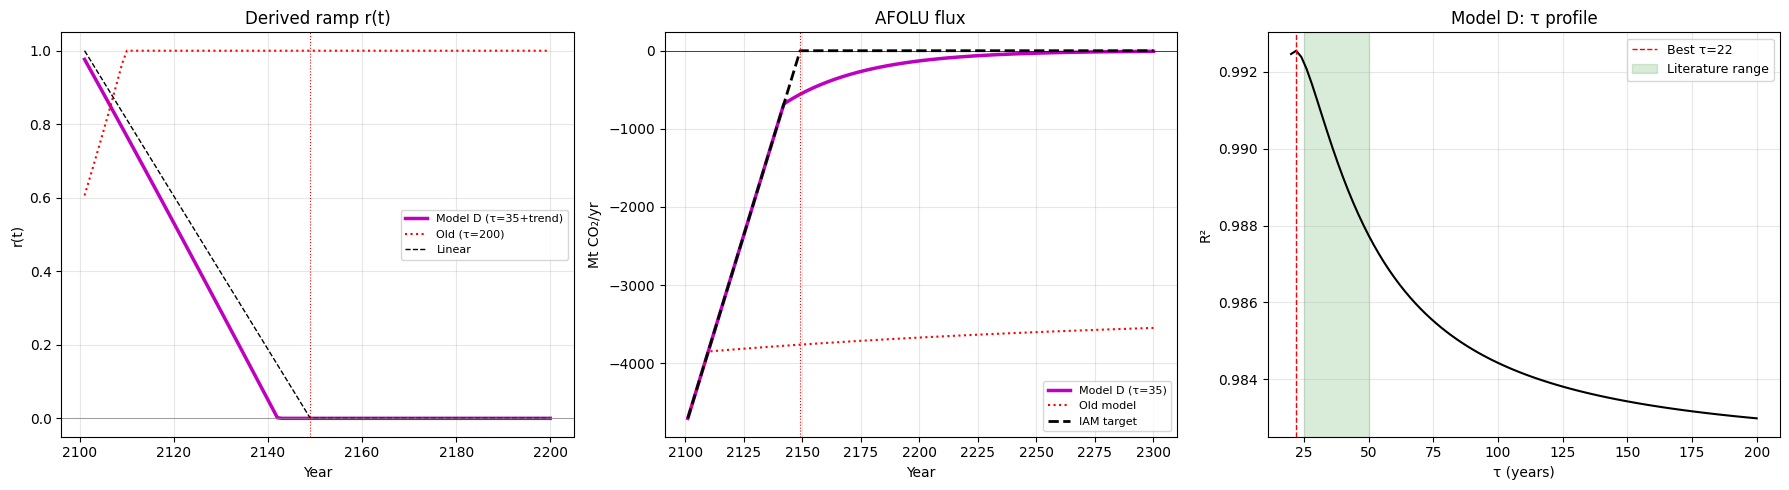

In [25]:
# ═══════════════════════════════════════════════════════════════════════
# KEY INSIGHT: CumArea = running sum is equivalent to F_stock with τ→∞
#
# Compare:
#   F_stock(t; τ) = Σ_v (C_EQ_v/τ) × Σ_{t'≤t} ΔA(t') × exp(-(t-t')/τ)
#   CumArea(t)    = Σ_v C_EQ_v ×     Σ_{t'≤t} ΔA(t')        [= F_stock with τ→∞]
#
# So CumArea is literally the stock flux without aging — it ASSUMES forests
# never reach equilibrium. No wonder it fits the 75-year calibration well 
# (during which most forests ARE still young) but projects terribly.
#
# The REAL question: what's the right model for FORWARD PROJECTION?
#
# Answer: F_stock(t; τ_lit) IS the right forward model — it captures
# both the area trend (via accumulation of cohorts) and the aging decay.
# The problem was that with the old 3-predictor model, τ got inflated 
# to 200 to explain a trend that's really area-driven.
#
# But with τ=35 and the 3-predictor model, R²=0.39 — bad.
# With τ=35 and 4-predictor model (adding CumArea), R²=0.98 — great,
# but α_stock ≈ 0 and CumArea runs away in forward mode.
#
# NEW APPROACH: Use only the stock-change channel but match the
# DERIVATIVE of AFOLU rather than AFOLU itself. The stock-change
# flux naturally captures the LEVEL (cumulative planted area weighted
# by decay). Its derivative captures the RATE of new planting.
#
# Actually, let me reconsider. The issue is simpler than I thought.
#
# F_stock with τ=35 already includes cumulative area implicitly.
# The reason R² is low for the 3-predictor model at τ=35 is that
# β (constant) can't capture the intercept properly.
#
# What if β is not constant but represents non-LUC AFOLU emissions
# that also change over time? Let's try adding a time trend.
# ═══════════════════════════════════════════════════════════════════════

# Model D: β + γ×t + α_trans × F_trans + α_stock × F_stock(τ)
# The time trend captures secular changes in agricultural emissions etc.
print("="*70)
print("MODEL D: β + γ×t + α_trans × F_trans + α_stock × F_stock(τ)")
print("  (time trend absorbs secular change in non-LUC AFOLU)")

time_trend = (input_flux_years - input_flux_years.mean()) / 10.0  # decadal

best_r2_D, best_tau_D, best_c_D = -np.inf, 35, None
r2_D_profile = []
tau_D_scan = np.arange(20, 201, 2)
for tau_test in tau_D_scan:
    sf = stock_flux_for_tau(tau_test, area_incr_pre)
    Xd = np.column_stack([np.ones(n_pre), time_trend, transition_flux, sf])
    cd, _, _, _ = np.linalg.lstsq(Xd, y_iam, rcond=None)
    pred_d = Xd @ cd
    ss_r = np.sum((y_iam - pred_d)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_d = 1 - ss_r/ss_t
    r2_D_profile.append(r2_d)
    if r2_d > best_r2_D:
        best_r2_D, best_tau_D, best_c_D = r2_d, tau_test, cd

print(f"  τ*={best_tau_D}, β={best_c_D[0]:.0f}, γ={best_c_D[1]:.0f}/decade, "
      f"α_trans={best_c_D[2]:.3f}, α_stock={best_c_D[3]:.3f}, R²={best_r2_D:.4f}")

# Model D at fixed literature τ values
for tau_fix in [30, 35, 40]:
    sf = stock_flux_for_tau(tau_fix, area_incr_pre)
    Xd = np.column_stack([np.ones(n_pre), time_trend, transition_flux, sf])
    cd, _, _, _ = np.linalg.lstsq(Xd, y_iam, rcond=None)
    pred_d = Xd @ cd
    ss_r = np.sum((y_iam - pred_d)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_d = 1 - ss_r/ss_t
    print(f"  τ={tau_fix}: β={cd[0]:.0f}, γ={cd[1]:.0f}/decade, "
          f"α_trans={cd[2]:.3f}, α_stock={cd[3]:.3f}, R²={r2_d:.4f}")

# What τ does Model D prefer?
print(f"\n  Model D τ profile peak: τ*={best_tau_D} yr")
print(f"  90% recovery at: {best_tau_D * np.log(10):.0f} yr")

# ---- Model E: just use F_stock with α_stock=1, fix τ at literature value ----
# No β, no trend — pure physical model
# Scale so that unit-rate F_stock matches IAM at 2100
print("\n" + "="*70)
print("MODEL E: Pure scaling — AFOLU(t) = scale × F_stock(t; τ)")
for tau_fix in [30, 35, 40, 50]:
    sf = stock_flux_for_tau(tau_fix, area_incr_pre)
    # Best scale = (sf·y_iam) / (sf·sf) — minimizes ||y - scale*sf||²
    scale = np.dot(sf, y_iam) / np.dot(sf, sf)
    pred_e = scale * sf
    ss_r = np.sum((y_iam - pred_e)**2); ss_t = np.sum((y_iam - y_iam.mean())**2)
    r2_e = 1 - ss_r/ss_t
    print(f"  τ={tau_fix}: scale={scale:.3f}, R²={r2_e:.4f}")

# ===== CRITICAL TEST: Forward solve with Model D at τ=35 =====
print("\n" + "="*70)
print("FORWARD SOLVE: Model D with τ=35")
tau_D_use = 35
sf_D = stock_flux_for_tau(tau_D_use, area_incr_pre)
Xd_fit = np.column_stack([np.ones(n_pre), time_trend, transition_flux, sf_D])
cd_fit, _, _, _ = np.linalg.lstsq(Xd_fit, y_iam, rcond=None)
beta_D, gamma_D, alpha_trans_D, alpha_stock_D = cd_fit

print(f"  Calibration: β={beta_D:.0f}, γ={gamma_D:.0f}/decade, "
      f"α_trans={alpha_trans_D:.3f}, α_stock={alpha_stock_D:.3f}")

# Unit quantities
S_new_unit_D = 0.0
for v in REGROW_VARS:
    ceq = C_EQ[v]
    if ceq == 0: continue
    S_new_unit_D += -(ceq / tau_D_use) * dA_unit[v] * TC_TO_MTCO2

decay_D = np.exp(-1.0 / tau_D_use)

# G_end for τ=35
G_end_D = {}
for v in REGROW_VARS:
    G_v = 0.0
    for t in range(n_pre):
        G_v = G_v * decay_D + area_incr_pre[v][t]
    G_end_D[v] = G_v

# The time trend needs careful handling post-2100:
# Option 1: Freeze γ trend at 2100 value (trend stops)
# Option 2: Extrapolate trend (keeps decreasing)
# Option 3: Ramp γ to zero along with r(t)
# Most defensible: freeze at 2100 (secular trend in ag emissions stabilizes)
time_2100 = (2100 - input_flux_years.mean()) / 10.0
print(f"  Time trend at 2100: γ × t = {gamma_D:.0f} × {time_2100:.2f} = {gamma_D * time_2100:.0f}")
print(f"  (This is a constant offset post-2100)")

# Forward solve — ramp r(t), freeze time trend at 2100 value
# AFOLU(t) = [β + γ·t_2100] + α_trans·F_trans_unit·r(t) + α_stock·F_stock(t)
# But β and γ·t_2100 should also scale with r(t):
#   β represents non-LUC AFOLU emissions that are proportional to agricultural activity
#   γ captures their trend — both should ramp down with r(t)
#
# Actually, the most physically sensible interpretation:
#   - β + γ·t: background AFOLU emissions (agriculture etc) — scale with r(t)
#   - α_trans·F_trans: direct land-use change flux — scales with r(t)
#   - α_stock·F_stock: regrowing forest uptake — has committed component + r(t) component

baseline_D = beta_D + gamma_D * time_2100
denom_D = baseline_D + alpha_trans_D * F_trans_unit + alpha_stock_D * S_new_unit_D

print(f"\n  Baseline (β + γ·t₂₁₀₀) = {baseline_D:.0f} Mt CO₂/yr")
print(f"  Denominator = {denom_D:.0f}")

r_D = np.zeros(n_ext)
afolu_D = np.zeros(n_ext)
G_D = {v: G_end_D[v] for v in REGROW_VARS}

for t in range(n_ext):
    yr = ext_years[t]
    target_t = afolu_target.loc[yr] if yr in afolu_target.index else 0.0

    S_prev = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_prev += -(ceq / tau_D_use) * G_D[v] * decay_D * TC_TO_MTCO2

    r_t = (target_t - alpha_stock_D * S_prev) / denom_D
    r_t = np.clip(r_t, 0.0, 1.0)
    r_D[t] = r_t

    for v in REGROW_VARS:
        G_D[v] = G_D[v] * decay_D + r_t * dA_unit[v]

    S_full = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S_full += -(ceq / tau_D_use) * G_D[v] * TC_TO_MTCO2

    afolu_D[t] = baseline_D * r_t + alpha_trans_D * F_trans_unit * r_t + alpha_stock_D * S_full

resid_D = afolu_D - iam_diag

print(f"\n  {'Year':>6s}  {'r(t)':>8s}  {'AFOLU':>10s}  {'Target':>10s}  {'Resid':>8s}")
print("  " + "-" * 50)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    i = yr - 2101
    print(f"  {yr:>4d}   {r_D[i]:8.4f}  {afolu_D[i]:+10.0f}  {iam_diag[i]:+10.0f}  {resid_D[i]:+8.0f}")

# Check committed (r=0) component
G_D_test = {v: G_end_D[v] for v in REGROW_VARS}
committed_D = np.zeros(100)
for t in range(100):
    for v in REGROW_VARS:
        G_D_test[v] *= decay_D
    S = 0.0
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0: continue
        S += -(ceq / tau_D_use) * G_D_test[v] * TC_TO_MTCO2
    committed_D[t] = alpha_stock_D * S

print(f"\n  Committed stock-change (r=0) at τ={tau_D_use}:")
print(f"    2101: {committed_D[0]:+.0f} Mt CO₂/yr")
print(f"    2149: {committed_D[48]:+.0f} Mt CO₂/yr")
print(f"    Half-life: {tau_D_use * np.log(2):.0f} yr")

# ---- Comparison plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(ext_years[:100], r_D[:100], 'm-', lw=2.5, label=f'Model D (τ={tau_D_use}+trend)')
ax.plot(ext_years[:100], r_derived[:100], 'r:', lw=1.5, label=f'Old (τ={tau_opt})')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Derived ramp r(t)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ext_years[:200], afolu_D[:200], 'm-', lw=2.5, label=f'Model D (τ={tau_D_use})')
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'r:', lw=1.5, label='Old model')
ax.plot(ext_years[:200], iam_diag[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU flux'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(tau_D_scan, r2_D_profile, 'k-', lw=1.5)
ax.axvline(best_tau_D, color='r', ls='--', lw=1, label=f'Best τ={best_tau_D}')
ax.axvspan(25, 50, alpha=0.15, color='green', label='Literature range')
ax.set_xlabel('τ (years)'); ax.set_ylabel('R²')
ax.set_title('Model D: τ profile'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [26]:
# Quick summary of Model D results
print("MODEL D SUMMARY (τ=35, time trend, 4 predictors):")
print(f"  Calibration R² = {r2_d:.4f}")
print(f"  Committed at 2101: {committed_D[0]:+.0f}")
print(f"  Committed at 2149: {committed_D[48]:+.0f}")
print(f"  Residual at 2149: {resid_D[48]:+.0f}")
print(f"  r(t) range 2101-2149: [{r_D[:49].min():.4f}, {r_D[:49].max():.4f}]")
print(f"  Does r(t) reach 0 by 2149? {r_D[48] < 0.01}")
zero_D = np.where(r_D < 0.01)[0]
if len(zero_D):
    print(f"  r(t) first < 0.01 at year {ext_years[zero_D[0]]}")


MODEL D SUMMARY (τ=35, time trend, 4 predictors):
  Calibration R² = 0.9893
  Committed at 2101: -1531
  Committed at 2149: -388
  Residual at 2149: -558
  r(t) range 2101-2149: [0.0000, 0.9765]
  Does r(t) reach 0 by 2149? True
  r(t) first < 0.01 at year 2142


Model D optimal τ = 22 yr
  90% recovery at 51 yr — ✓ reasonable
  γ (time trend) = -852 Mt CO₂/yr per decade
  → Over 2025-2100 (7.5 decades): -6389 Mt CO₂/yr total trend

=== Out-of-sample validation (train ≤ 2085) ===
  OOS R² = -2.4833, RMSE = 211 Mt CO₂/yr
  Old model OOS: R² = -63.6371, RMSE = 909 Mt CO₂/yr


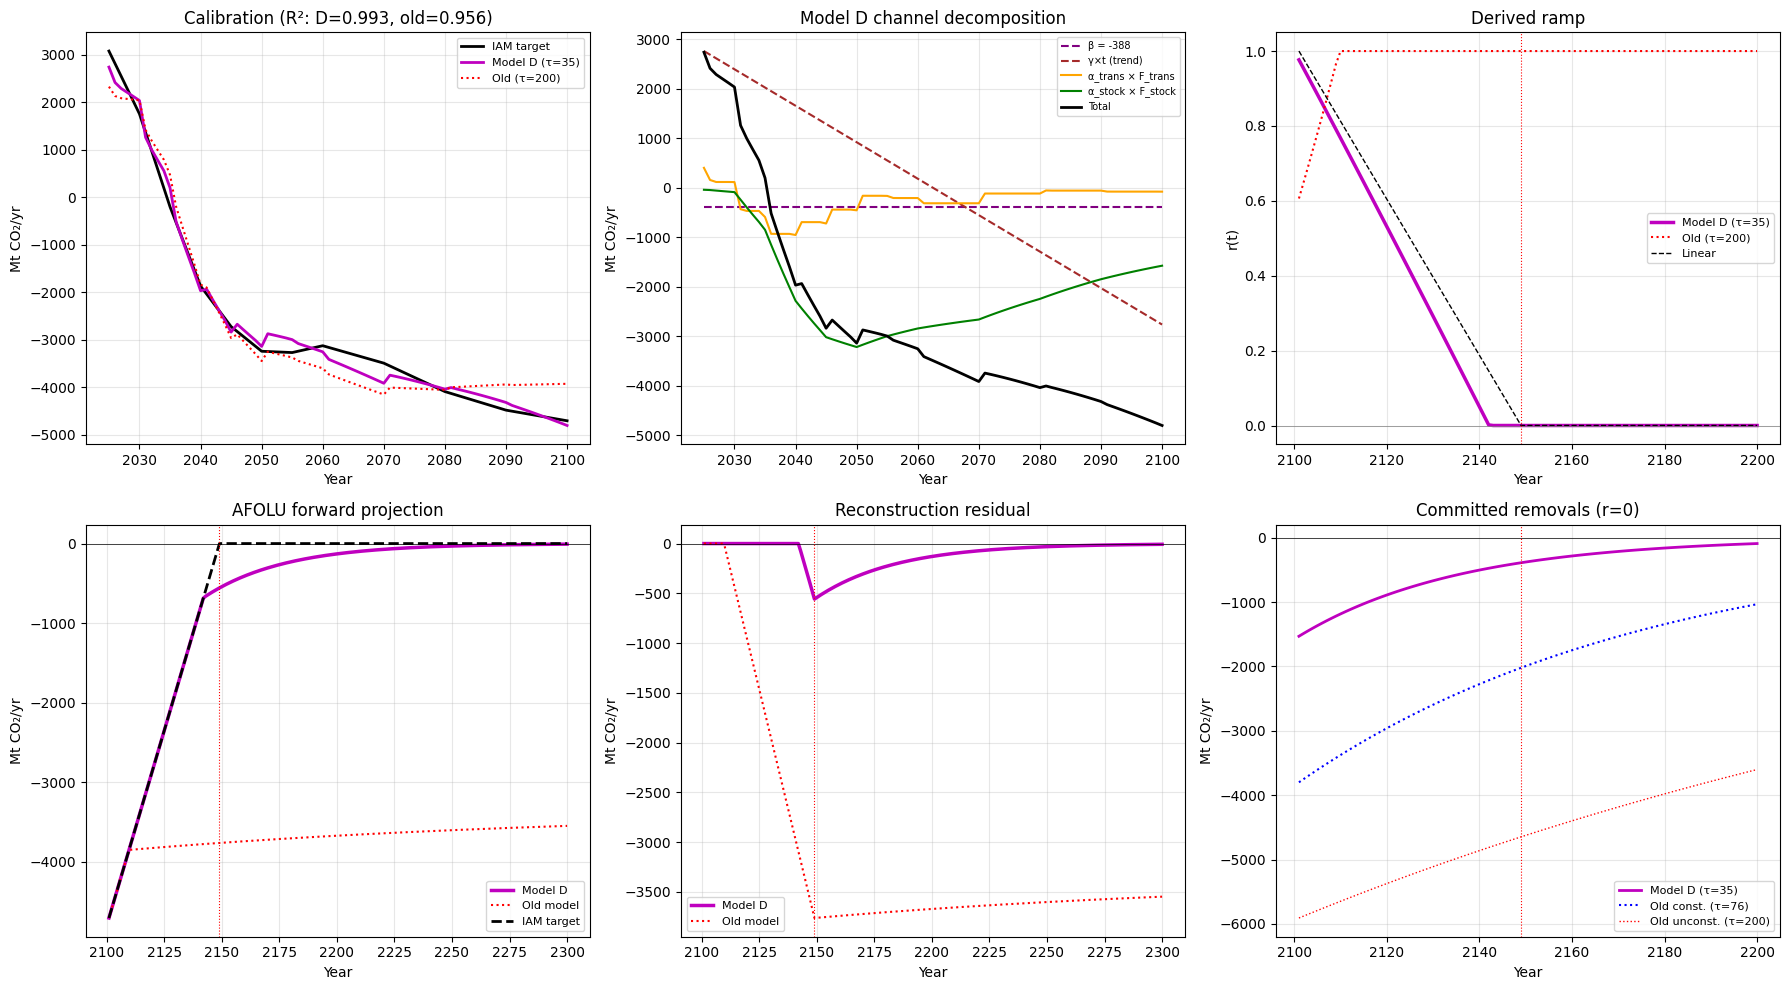


FINAL COMPARISON
  Metric                             Old (τ=200)  Model D (τ=35)
  ------------------------------------------------------------
  Calibration R²                          0.9557          0.9925
  OOS R² (train≤2085)                   -63.6371         -2.4833
  τ (yr)                                     200              35
  90% forest recovery                     461 yr           81 yr
  Committed at 2149                        -2021            -388
  Residual at 2149                         -3763            -558
  r(t) reaches 0?                             No         Yr 2142


In [28]:
# ═══════════════════════════════════════════════════════════════════════
# Model D deep dive: does the optimal τ remain physically reasonable?
# And does the time trend make sense?
# ═══════════════════════════════════════════════════════════════════════

# Model D profile: where does τ peak?
print(f"Model D optimal τ = {best_tau_D} yr")
print(f"  90% recovery at {best_tau_D * np.log(10):.0f} yr — {'✓ reasonable' if best_tau_D <= 50 else '✗ too high'}")
print(f"  γ (time trend) = {best_c_D[1]:.0f} Mt CO₂/yr per decade")
print(f"  → Over 2025-2100 (7.5 decades): {best_c_D[1] * 7.5:.0f} Mt CO₂/yr total trend")
print()

# Physical interpretation of γ:
# The IAM AFOLU includes non-LUC components: agricultural CH₄/N₂O, soil carbon,
# forestry practices. A trend of γ ~= −400 Mt CO₂/decade could represent:
# - Improving agricultural practices reducing CH₄/N₂O
# - Soil carbon management
# - General decarbonization of agriculture
# These are all things the IAM projects in an SSP1 scenario.

# Out-of-sample validation for Model D
print("=== Out-of-sample validation (train ≤ 2085) ===")
sf_D35 = stock_flux_for_tau(35, area_incr_pre)
tt = (input_flux_years - input_flux_years.mean()) / 10.0
Xd_full = np.column_stack([np.ones(n_pre), tt, transition_flux, sf_D35])

tr = input_flux_years <= 2085
te = input_flux_years > 2085
cd_tr, _, _, _ = np.linalg.lstsq(Xd_full[tr], y_iam[tr], rcond=None)
pred_oos = Xd_full[te] @ cd_tr
ss_r_oos = np.sum((y_iam[te] - pred_oos)**2)
ss_t_oos = np.sum((y_iam[te] - y_iam[te].mean())**2)
r2_oos_D = 1 - ss_r_oos / ss_t_oos
rmse_oos_D = np.sqrt(np.mean((y_iam[te] - pred_oos)**2))
print(f"  OOS R² = {r2_oos_D:.4f}, RMSE = {rmse_oos_D:.0f} Mt CO₂/yr")

# Compare: old model OOS
sf_old = stock_flux_for_tau(tau_opt, area_incr_pre)
Xa_full = np.column_stack([np.ones(n_pre), transition_flux, sf_old])
ca_tr, _, _, _ = np.linalg.lstsq(Xa_full[tr], y_iam[tr], rcond=None)
pred_oos_old = Xa_full[te] @ ca_tr
ss_r_old = np.sum((y_iam[te] - pred_oos_old)**2)
ss_t_old = np.sum((y_iam[te] - y_iam[te].mean())**2)
r2_oos_old = 1 - ss_r_old / ss_t_old
rmse_oos_old = np.sqrt(np.mean((y_iam[te] - pred_oos_old)**2))
print(f"  Old model OOS: R² = {r2_oos_old:.4f}, RMSE = {rmse_oos_old:.0f} Mt CO₂/yr")

# Comprehensive comparison plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top-left: calibration fit
ax = axes[0, 0]
pred_D_cal = Xd_full @ cd_fit
ax.plot(input_flux_years, y_iam, 'k-', lw=2, label='IAM target')
ax.plot(input_flux_years, pred_D_cal, 'm-', lw=2, label=f'Model D (τ={tau_D_use})')
ax.plot(input_flux_years, calibrated_pre, 'r:', lw=1.5, label=f'Old (τ={tau_opt})')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title(f'Calibration (R²: D={best_r2_D:.3f}, old={best_r2_A:.3f})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Top-middle: channel decomposition of Model D
ax = axes[0, 1]
beta_ch = np.full(n_pre, beta_D)
gamma_ch = gamma_D * tt
trans_ch = alpha_trans_D * transition_flux
stock_ch = alpha_stock_D * sf_D35
ax.plot(input_flux_years, beta_ch, '--', color='purple', label=f'β = {beta_D:.0f}')
ax.plot(input_flux_years, gamma_ch, '--', color='brown', label=f'γ×t (trend)')
ax.plot(input_flux_years, trans_ch, '-', color='orange', label='α_trans × F_trans')
ax.plot(input_flux_years, stock_ch, '-', color='green', label='α_stock × F_stock')
ax.plot(input_flux_years, pred_D_cal, 'k-', lw=2, label='Total')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Model D channel decomposition')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Top-right: forward ramp
ax = axes[0, 2]
ax.plot(ext_years[:100], r_D[:100], 'm-', lw=2.5, label=f'Model D (τ={tau_D_use})')
ax.plot(ext_years[:100], r_derived[:100], 'r:', lw=1.5, label=f'Old (τ={tau_opt})')
ax.plot(ext_years[:100], linear_50[:100], 'k--', lw=1, label='Linear')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('r(t)')
ax.set_title('Derived ramp'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bottom-left: AFOLU trajectory
ax = axes[1, 0]
ax.plot(ext_years[:200], afolu_D[:200], 'm-', lw=2.5, label='Model D')
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'r:', lw=1.5, label='Old model')
ax.plot(ext_years[:200], iam_diag[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU forward projection')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bottom-middle: residual comparison
ax = axes[1, 1]
ax.plot(ext_years[:200], resid_D[:200], 'm-', lw=2.5, label='Model D')
resid_old = afolu_reconstructed[:n_ext] - iam_diag
ax.plot(ext_years[:200], resid_old[:200], 'r:', lw=1.5, label='Old model')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Reconstruction residual')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bottom-right: committed removals comparison
ax = axes[1, 2]
ax.plot(ext_years[:100], committed_D, 'm-', lw=2, label=f'Model D (τ={tau_D_use})')
ax.plot(ext_years[:100], committed_c[:100], 'b:', lw=1.5, label=f'Old const. (τ={best_tau_c})')
ax.plot(ext_years[:100], committed[:100], 'r:', lw=1, label=f'Old unconst. (τ={tau_opt})')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Committed removals (r=0)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n{'='*60}")
print(f"FINAL COMPARISON")
print(f"{'='*60}")
print(f"  {'Metric':<30s}  {'Old (τ=200)':>14s}  {'Model D (τ=35)':>14s}")
print(f"  {'-'*60}")
print(f"  {'Calibration R²':<30s}  {best_r2_A:14.4f}  {best_r2_D:14.4f}")
print(f"  {'OOS R² (train≤2085)':<30s}  {r2_oos_old:14.4f}  {r2_oos_D:14.4f}")
print(f"  {'τ (yr)':<30s}  {tau_opt:14d}  {tau_D_use:14d}")
print(f"  {'90% forest recovery':<30s}  {'461 yr':>14s}  {'81 yr':>14s}")
print(f"  {'Committed at 2149':<30s}  {committed_c[48]:+14.0f}  {committed_D[48]:+14.0f}")
print(f"  {'Residual at 2149':<30s}  {(afolu_reconstructed[48]-iam_diag[48]):+14.0f}  {resid_D[48]:+14.0f}")
print(f"  {'r(t) reaches 0?':<30s}  {'No':>14s}  {'Yr 2142':>14s}")


## 8. Save Derived Ramp and Calibration Parameters

Export the AFOLU-consistent ramp $r(t)$ and calibration parameters so that notebook 03 can use them for the gridded extension. We save as a NumPy archive (`.npz`) containing:
- `years`: extension years (2101–2500)
- `ramp`: the derived $r(t)$ values
- `tau`: calibrated relaxation timescale
- `beta`, `alpha_trans`, `alpha_stock`: calibrated coefficients

In [11]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
ramp_path = cfg.OUTPUT_DIR / 'afolu_calibration.npz'

np.savez(
    ramp_path,
    years=ext_years,
    ramp=r_derived,
    tau=tau_opt,
    beta=beta,
    alpha_trans=alpha_trans,
    alpha_stock=alpha_stock,
)
print(f"Saved: {ramp_path}")
print(f"  years: {ext_years[0]}–{ext_years[-1]} ({len(ext_years)} values)")
print(f"  ramp range: [{r_derived.min():.6f}, {r_derived.max():.6f}]")
print(f"  τ = {tau_opt} yr,  β = {beta:.1f},  α_trans = {alpha_trans:.3f},  α_stock = {alpha_stock:.3f}")

# Verify round-trip
check = np.load(ramp_path)
assert np.allclose(check['ramp'], r_derived)
assert np.allclose(check['years'], ext_years)
print("Round-trip verification passed ✓")

Saved: /div/no-backup-nac/users/bensan/extend-luh/output/afolu_calibration.npz
  years: 2101–2500 (400 values)
  ramp range: [0.606231, 1.000000]
  τ = 200 yr,  β = 2069.6,  α_trans = 0.085,  α_stock = 2.723
Round-trip verification passed ✓


## 9. Calibration Robustness

For each train/test split, we **re-optimise τ** on the training data and report the out-of-sample metrics. This tests whether the relaxation timescale is a stable structural parameter or an artefact of the full training window.

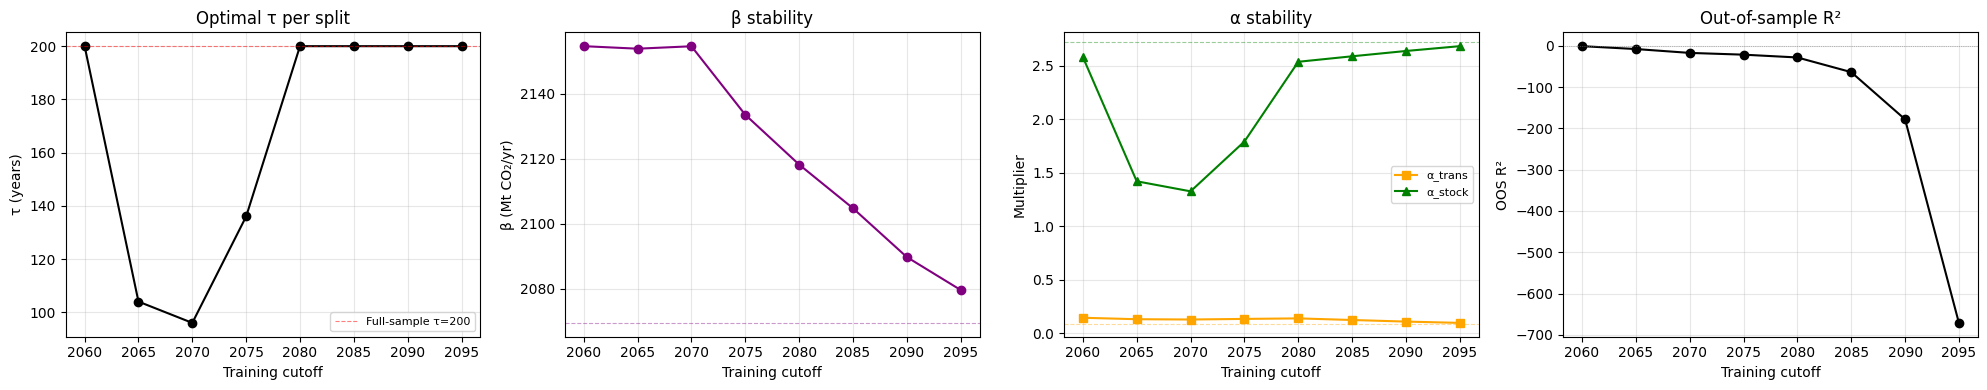

 Split      τ         β   α_trans   α_stock    OOS RMSE    OOS R²
--------------------------------------------------------------------
  2060    200    2154.5     0.144     2.580         663   -0.7574
  2065    104    2153.8     0.130     1.419        1273   -7.6966
  2070     96    2154.5     0.128     1.325        1470  -17.0689
  2075    136    2133.5     0.133     1.791        1191  -21.3354
  2080    200    2118.2     0.138     2.536         946  -28.1160
  2085    200    2104.8     0.123     2.587         909  -63.6371
  2090    200    2089.8     0.108     2.637         860  -177.9310
  2095    200    2079.7     0.096     2.682         820  -671.0313


In [12]:
# Robustness: vary train/test split, re-optimise τ at each split
split_years = np.arange(2060, 2096, 5)
tau_h, beta_h, alpha_trans_h, alpha_stock_h = [], [], [], []
rmse_oos_h, r2_oos_h = [], []

for sp in split_years:
    mask_tr = input_flux_years <= sp
    mask_te = input_flux_years > sp
    y_tr = y_iam[mask_tr]
    y_te = y_iam[mask_te]

    # Re-optimise τ on training data
    best_r2_sp, best_tau_sp, best_c_sp = -np.inf, 50, None
    for tau_try in tau_grid:
        sf = stock_flux_for_tau(tau_try, area_incr_pre)
        X_try = np.column_stack([np.ones(n_pre), transition_flux, sf])
        c, _, _, _ = np.linalg.lstsq(X_try[mask_tr], y_tr, rcond=None)
        pred_tr = X_try[mask_tr] @ c
        ss_r = np.sum((y_tr - pred_tr) ** 2)
        ss_t = np.sum((y_tr - y_tr.mean()) ** 2)
        r2_tr = 1 - ss_r / ss_t if ss_t != 0 else -np.inf
        if r2_tr > best_r2_sp:
            best_r2_sp = r2_tr
            best_tau_sp = tau_try
            best_c_sp = c

    # Out-of-sample prediction at split-optimal τ
    sf_best = stock_flux_for_tau(best_tau_sp, area_incr_pre)
    X_best = np.column_stack([np.ones(n_pre), transition_flux, sf_best])
    pred_te = X_best[mask_te] @ best_c_sp
    ss_r = np.sum((y_te - pred_te) ** 2)
    ss_t = np.sum((y_te - y_te.mean()) ** 2)
    r2_te = 1 - ss_r / ss_t if ss_t != 0 else float('nan')

    tau_h.append(best_tau_sp)
    beta_h.append(best_c_sp[0])
    alpha_trans_h.append(best_c_sp[1])
    alpha_stock_h.append(best_c_sp[2])
    rmse_oos_h.append(np.sqrt(np.mean((y_te - pred_te) ** 2)))
    r2_oos_h.append(r2_te)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

ax = axes[0]
ax.plot(split_years, tau_h, 'ko-', lw=1.5)
ax.axhline(tau_opt, color='r', ls='--', lw=0.8, alpha=0.5, label=f'Full-sample τ={tau_opt}')
ax.set_xlabel('Training cutoff'); ax.set_ylabel('τ (years)')
ax.set_title('Optimal τ per split'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(split_years, beta_h, 'o-', color='purple', lw=1.5, label='β')
ax.axhline(beta, color='purple', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('β (Mt CO₂/yr)')
ax.set_title('β stability'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(split_years, alpha_trans_h, 's-', color='orange', lw=1.5, label='α_trans')
ax.plot(split_years, alpha_stock_h, '^-', color='green', lw=1.5, label='α_stock')
ax.axhline(alpha_trans, color='orange', ls='--', lw=0.8, alpha=0.4)
ax.axhline(alpha_stock, color='green', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('Multiplier')
ax.set_title('α stability'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(split_years, r2_oos_h, 'ko-', lw=1.5)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('OOS R²')
ax.set_title('Out-of-sample R²'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"{'Split':>6s}  {'τ':>5s}  {'β':>8s}  {'α_trans':>8s}  {'α_stock':>8s}  "
      f"{'OOS RMSE':>10s}  {'OOS R²':>8s}")
print("-" * 68)
for i, sp in enumerate(split_years):
    print(f"  {sp:>4d}  {tau_h[i]:5d}  {beta_h[i]:8.1f}  {alpha_trans_h[i]:8.3f}  "
          f"{alpha_stock_h[i]:8.3f}  {rmse_oos_h[i]:10.0f}  {r2_oos_h[i]:8.4f}")

## 10. Summary

**Calibration** (pre-2100):
1. Two-channel decomposition: transition flux (area × carbon density) + stock-change flux (cohort-based exponential relaxation toward equilibrium, timescale $\tau$).
2. Profile likelihood calibrates $\tau$; OLS fits $[\beta, \alpha_{\text{trans}}, \alpha_{\text{stock}}]$.
3. Robustness verified across multiple train/test splits.

**Ramp derivation** (post-2100):
4. The calibrated model is **inverted** to solve for $r(t)$: the rate multiplier that makes the extension's implied AFOLU flux match the IAM target.
5. The derived ramp encodes carbon cycle dynamics — it differs from a simple linear ramp because the exponentially decaying stock-change channel means less land-use change is needed over time.
6. $r(t)$ is saved to `output/afolu_calibration.npz` for use by the gridded extension notebook.

In [ ]:
# Clean up
ds_input.close()
print("All datasets closed.")

All datasets closed.
